In [1]:
import numpy as np
import pandas as pd
from joblib import dump
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Pour les performances de classification
from imblearn.under_sampling import RandomUnderSampler
from keras.optimizers import SGD,Adam
from datetime import datetime
maintenant = datetime.now()
print(maintenant)
import tensorflow as tf

# activation GPU

gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)




from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense # Pour construire un réseau de neurones et
                                                 # instancier une couche d'entrée et une couche den
from sklearn.ensemble import RandomForestClassifier # Pour instancier et entraîner un modèle Random Forest
import matplotlib.pyplot as plt
import os
#import cv2
import gc
import itertools # Pour créer des itérateurs
import pickle

2024-03-18 07:55:36.301464
1 Physical GPUs, 1 Logical GPUs


In [2]:
VERSION = "_V01"
SUFFIXE_FICHIER = "VGG16" + VERSION
STRATEGIE = "sampling_strategy_VGG16" + VERSION +".csv" # effectifs par classe retenu après over et under sampling
IMGSIZE       = 400    # Taille de l'image en input
EPOCH         = 20     # nombre d'epoch 
BATCH_SIZE    = 32     # traitement par batch d'images avant la descente de gradient
FREEZE_LAYERS = 15    # pour un VGG16 freeze de réapprentissage de certaines couches
NB_PAR_LABEL_MAX = 5000 # nombre maximun d'enregistrement par label = undersampling
NB_PAR_LABEL_MIN = 2000 # nombre maximun d'enregistrement par label = oversampling
TRAIN         = True   # Entrainement ou utilisation d'un réseau déjà entrainé

In [3]:
import sys
sys.path.append('../src')
import Bibli_DataScience_3_2 as ds
import CNN_DataScience_2 as cnn

section :  ['DOSSIER', 'FICHIER']


In [4]:
# Pour recharger si nesséssaire
import imp
imp.reload(ds)
imp.reload(cnn)

section :  ['DOSSIER', 'FICHIER']


<module 'CNN_DataScience_2' from 'E:\\Manuel\\PROJET\\Rakuten_Images_Classification_TensorFlow\\notebooks\\../src\\CNN_DataScience_2.py'>

In [4]:
# lecture des données sources d'entrainement
df_feats=pd.read_csv(ds.get_RACINE_DOSSIER() + 'X_train_update.csv')

# lecture des données cibles d'entrainement
df_target=pd.read_csv(ds.get_RACINE_DOSSIER() + 'Y_train_CVw08PX.csv')


# création d'un dataframe globale -  jointure
df=df_feats.merge(df_target,on='Unnamed: 0',how='inner')
df.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)
#cat=df_target['prdtypecode'].sort_values().unique()
nomenclature=pd.read_csv(ds.get_RACINE_DOSSIER() + 'NOMENCLATURE.csv',header=0,encoding='utf-8',sep=';',index_col=0)
catdict=nomenclature.to_dict()['definition']
Lcat=df_target.sort_values(by = ['prdtypecode'])['prdtypecode'].unique()
Lcat

array([  10,   40,   50,   60, 1140, 1160, 1180, 1280, 1281, 1300, 1301,
       1302, 1320, 1560, 1920, 1940, 2060, 2220, 2280, 2403, 2462, 2522,
       2582, 2583, 2585, 2705, 2905], dtype=int64)

In [5]:
df['nom_image']=df.apply(lambda row: "image_" +  str(row['imageid']) 
                                     + "_product_" + str(row['productid']) + ".jpg",axis=1)
print("Nb enreg ", str(df.shape[0]))
print(df.head(5))
df_img=df.copy()

Nb enreg  84916
   Id                                        designation  \
0   0  Olivia: Personalisiertes Notizbuch / 150 Seite...   
1   1  Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...   
2   2  Grand Stylet Ergonomique Bleu Gamepad Nintendo...   
3   3  Peluche Donald - Europe - Disneyland 2000 (Mar...   
4   4                               La Guerre Des Tuques   

                                         description   productid     imageid  \
0                                                NaN  3804725264  1263597046   
1                                                NaN   436067568  1008141237   
2  PILOT STYLE Touch Pen de marque Speedlink est ...   201115110   938777978   
3                                                NaN    50418756   457047496   
4  Luc a des id&eacute;es de grandeur. Il veut or...   278535884  1077757786   

   prdtypecode                                nom_image  
0           10  image_1263597046_product_3804725264.jpg  
1         2280   image_100

In [6]:
folder_path = ds.get_RACINE_IMAGES() 
df['filepath']=df['nom_image'].apply(lambda x : os.path.join(folder_path, x))

## test de lecture d'image¶

Taille de l'image : (500, 500, 3)


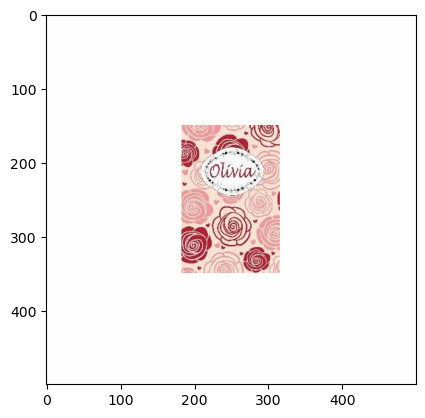

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
%matplotlib inline

# Chemin de l'image
filename = df.nom_image[0]
filepath = os.path.join(folder_path, filename)
# Lecture du fichier
im = tf.io.read_file(filepath)

# On décode le fichier
im = tf.image.decode_jpeg(im, channels=3)

print("Taille de l'image :", im.shape)

# Affichage du tensor
plt.imshow(im);

### REDIMENSIONNEMENT
Pour avoir un temps d'entrainement du modèle raisonnable,  
il est nécessaire de redimensionner les images.  
**A l'origine les images ont une taille de 500*500 pixels.**

In [8]:
filepath = df.filepath[0]
# Lecture du fichier
im = tf.io.read_file(filepath)
# On décode le fichier
im = tf.image.decode_jpeg(im, channels=3)
# Redimensionnement
tf.image.resize(im, size=(IMGSIZE,IMGSIZE))


<tf.Tensor: shape=(400, 400, 3), dtype=float32, numpy=
array([[[254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.]],

       [[254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.]],

       [[254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.]],

       ...,

       [[254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.]],

       [[254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.]],

       [[254., 25

### Evaluation de la répartition des catégories

In [9]:
y_serie =pd.Series(df.prdtypecode).value_counts()
majority_class = y_serie.index[0]
print(majority_class)
y_serie

2583


prdtypecode
2583    10209
1560     5073
1300     5045
2060     4993
2522     4989
1280     4870
2403     4774
2280     4760
1920     4303
1160     3953
1320     3241
10       3116
2705     2761
1140     2671
2582     2589
40       2508
2585     2496
1302     2491
1281     2070
50       1681
2462     1421
2905      872
60        832
2220      824
1301      807
1940      803
1180      764
Name: count, dtype: int64

### UNDERSAMPLING
On effectue un undersampling définit par le paramètre : NB_PAR_LABEL_MAX (cf debut de programme)    
Ici **undersampling à 5000**

In [10]:
new_class_counts = y_serie.copy()
sampling_strategy=new_class_counts.to_dict()
for key in sampling_strategy:
  if sampling_strategy[key] > NB_PAR_LABEL_MAX:
    sampling_strategy[key] = NB_PAR_LABEL_MAX
del y_serie,new_class_counts
#print(type(sampling_strategy))
spstrag=pd.DataFrame.from_dict(sampling_strategy,orient='index').rename(columns={0:'Qunatity'})
spstrag.to_csv(ds.get_RACINE_SAUVEGARDE()+STRATEGIE)
print("Stategie de sampling")
sampling_strategy

Stategie de sampling


{2583: 5000,
 1560: 5000,
 1300: 5000,
 2060: 4993,
 2522: 4989,
 1280: 4870,
 2403: 4774,
 2280: 4760,
 1920: 4303,
 1160: 3953,
 1320: 3241,
 10: 3116,
 2705: 2761,
 1140: 2671,
 2582: 2589,
 40: 2508,
 2585: 2496,
 1302: 2491,
 1281: 2070,
 50: 1681,
 2462: 1421,
 2905: 872,
 60: 832,
 2220: 824,
 1301: 807,
 1940: 803,
 1180: 764}

In [11]:
print(df.filepath.shape)
print(df.prdtypecode.shape)
X=np.array(df.filepath)
y=np.array(df.prdtypecode)
X=X.reshape(-1,1)
y=y.reshape(-1,1)
X.shape

(84916,)
(84916,)


(84916, 1)

In [12]:

rUs = RandomUnderSampler(sampling_strategy=sampling_strategy)
X_ru, y_ru = rUs.fit_resample(X, y  )
#del   X_Reshape, y
#gc.collect()
print(len(X_ru))
print(len(X_ru))

79589
79589


In [13]:
from sklearn.model_selection import train_test_split

import numpy as np

X_train_ru, X_test_path, y_train_ru, y_test = train_test_split(X_ru, y_ru, train_size=0.8, random_state=1234,
                                                              stratify=y_ru,shuffle=True)

Après la répartition entre le jeu de test et le jeu d'entrainement  
**la classe la plus représentée** du jeu d'entrainement comporte **4000 occurences**

In [14]:
y_serie =pd.Series(y_train_ru).value_counts()
majority_class = y_serie.index[0]
print(majority_class)
y_serie

1560


1560    4000
1300    4000
2583    4000
2060    3994
2522    3991
1280    3896
2403    3819
2280    3808
1920    3442
1160    3162
1320    2593
10      2493
2705    2209
1140    2137
2582    2071
40      2006
2585    1997
1302    1993
1281    1656
50      1345
2462    1137
2905     698
60       666
2220     659
1301     646
1940     642
1180     611
Name: count, dtype: int64

### OVERSAMPLING
On effectue un oversampling définit par le paramètre : B_PAR_LABEL_MIN (cf debut de programme)   
On utilisera par la suite un génarateur d'images pour générer des images différentes de chaque enregistrement   
**ici oversampling à 2000.**

In [15]:
new_class_counts = y_serie.copy()
sampling_strategy=new_class_counts.to_dict()
for key in sampling_strategy:
  if sampling_strategy[key] <NB_PAR_LABEL_MIN :
  #if key in [1180,2220]:  
    sampling_strategy[key] = NB_PAR_LABEL_MIN
spstrag=pd.DataFrame.from_dict(sampling_strategy,orient='index').rename(columns={0:'Qunatity'})
spstrag.to_csv(ds.get_RACINE_SAUVEGARDE()+STRATEGIE)  
print("Stategie de sampling")
sampling_strategy

Stategie de sampling


{1560: 4000,
 1300: 4000,
 2583: 4000,
 2060: 3994,
 2522: 3991,
 1280: 3896,
 2403: 3819,
 2280: 3808,
 1920: 3442,
 1160: 3162,
 1320: 2593,
 10: 2493,
 2705: 2209,
 1140: 2137,
 2582: 2071,
 40: 2006,
 2585: 2000,
 1302: 2000,
 1281: 2000,
 50: 2000,
 2462: 2000,
 2905: 2000,
 60: 2000,
 2220: 2000,
 1301: 2000,
 1940: 2000,
 1180: 2000}

In [16]:
from imblearn.over_sampling import RandomOverSampler
rOs = RandomOverSampler(sampling_strategy=sampling_strategy)
X_train_path, y_train = rOs.fit_resample(X_train_ru, y_train_ru)
X_train_path, y_train = shuffle(X_train_path, y_train, random_state=42)

In [17]:
y_res_series = pd.Series(y_train).value_counts()
print(y_res_series)


2583    4000
1300    4000
1560    4000
2060    3994
2522    3991
1280    3896
2403    3819
2280    3808
1920    3442
1160    3162
1320    2593
10      2493
2705    2209
1140    2137
2582    2071
40      2006
1281    2000
2585    2000
1302    2000
2462    2000
60      2000
2220    2000
1940    2000
1180    2000
1301    2000
2905    2000
50      2000
Name: count, dtype: int64


In [18]:

X_train_path=X_train_path.reshape(-1,)
print(X_train_path.shape)
X_test_path=X_test_path.reshape(-1,)
print(X_test_path.shape)

(73621,)
(15918,)


### Sauvegarde des jeux de données traités

In [19]:


with open(ds.get_RACINE_SAUVEGARDE() + 'X_train_path.pkl', 'wb') as f:
    pickle.dump(X_train_path, f)
with open(ds.get_RACINE_SAUVEGARDE() + 'X_test_path.pkl', 'wb') as f:
    pickle.dump(X_test_path, f)

In [24]:
"""
print(X_train_path[:2])
print(y_train[:2])
print(X_test_path[:2])
print(y_test[:2])
"""

'\nprint(X_train_path[:2])\nprint(y_train[:2])\nprint(X_test_path[:2])\nprint(y_test[:2])\n'

In [20]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_classes_converted = label_encoder.fit_transform(y_train)
#y_classes_train = label_encoder.transform(y_train)
# Maintenant, utilisez to_categorical
y_train_Network = to_categorical(y_classes_converted)
y_classes_converted = label_encoder.transform(y_test)
#y_classes_test = label_encoder.transform(y_test)
# Maintenant, utilisez to_categorical
y_test_Network = to_categorical(y_classes_converted)
print(y_train_Network.shape)
print(y_test_Network.shape)
with open(ds.get_RACINE_SAUVEGARDE() + 'y_train.pkl', 'wb') as f:
    pickle.dump(y_train, f)
with open(ds.get_RACINE_SAUVEGARDE() + 'y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)

(73621, 27)
(15918, 27)


In [ ]:
### augmentation des données
random_flip_left_right -> Retournez aléatoirement une image horizontalement (de gauche à droite)
random_flip_up_down -> Retournez aléatoirement une image verticalement (du haut vers  le bas)
random_brightness -> Ajuster la luminosité par un facteur aléatoire
random_contrast -> Ajuster le contraste par un facteur aléatoire
image.rot90 -> Rotation de 90 degrés

In [21]:

@tf.function
def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    #image = tf.image.rot90(image, k=1) 
    image = tf.image.random_crop(image,[400,400, 3])
    return image



@tf.function
def load_and_augment_image(filepath, resize=(IMGSIZE,IMGSIZE)):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = augment_image(image)
    return tf.image.resize(image, resize)

@tf.function
def load_image(filepath, resize=(IMGSIZE,IMGSIZE)):
    im = tf.io.read_file(filepath)
    im = tf.image.decode_jpeg(im, channels=3)
    return tf.image.resize(im, resize)

dataset_train = tf.data.Dataset.from_tensor_slices((X_train_path, y_train_Network ))

dataset_train = dataset_train.map(lambda x, y : [load_and_augment_image(x),y], num_parallel_calls=-1).batch(BATCH_SIZE)
#dataset_train = dataset_train.map(lambda x, y : [load_image(x),y], num_parallel_calls=-1).batch(BATCH_SIZE)

dataset_test = tf.data.Dataset.from_tensor_slices((X_test_path, y_test_Network))

dataset_test = dataset_test.map(lambda x, y : [load_image(x),y], num_parallel_calls=-1).batch(BATCH_SIZE)

#dataset_train_aug = tf.data.Dataset.from_tensor_slices((X_train_path_aug, y_train_Network_aug))
#dataset_train_aug = dataset_train_aug.map(lambda x, y: [load_and_augment_image2(x), y], num_parallel_calls=-1).batch(32)



0 E:/Manuel/PROJET/Rakuten_Images_Classification_TensorFlow/data/images/image_train/image_1316136561_product_4200873005.jpg
1 E:/Manuel/PROJET/Rakuten_Images_Classification_TensorFlow/data/images/image_train/image_948476880_product_211186175.jpg
2 E:/Manuel/PROJET/Rakuten_Images_Classification_TensorFlow/data/images/image_train/image_1306638729_product_4168967862.jpg
3 E:/Manuel/PROJET/Rakuten_Images_Classification_TensorFlow/data/images/image_train/image_1255785265_product_3871117241.jpg
4 E:/Manuel/PROJET/Rakuten_Images_Classification_TensorFlow/data/images/image_train/image_1060683016_product_179486743.jpg


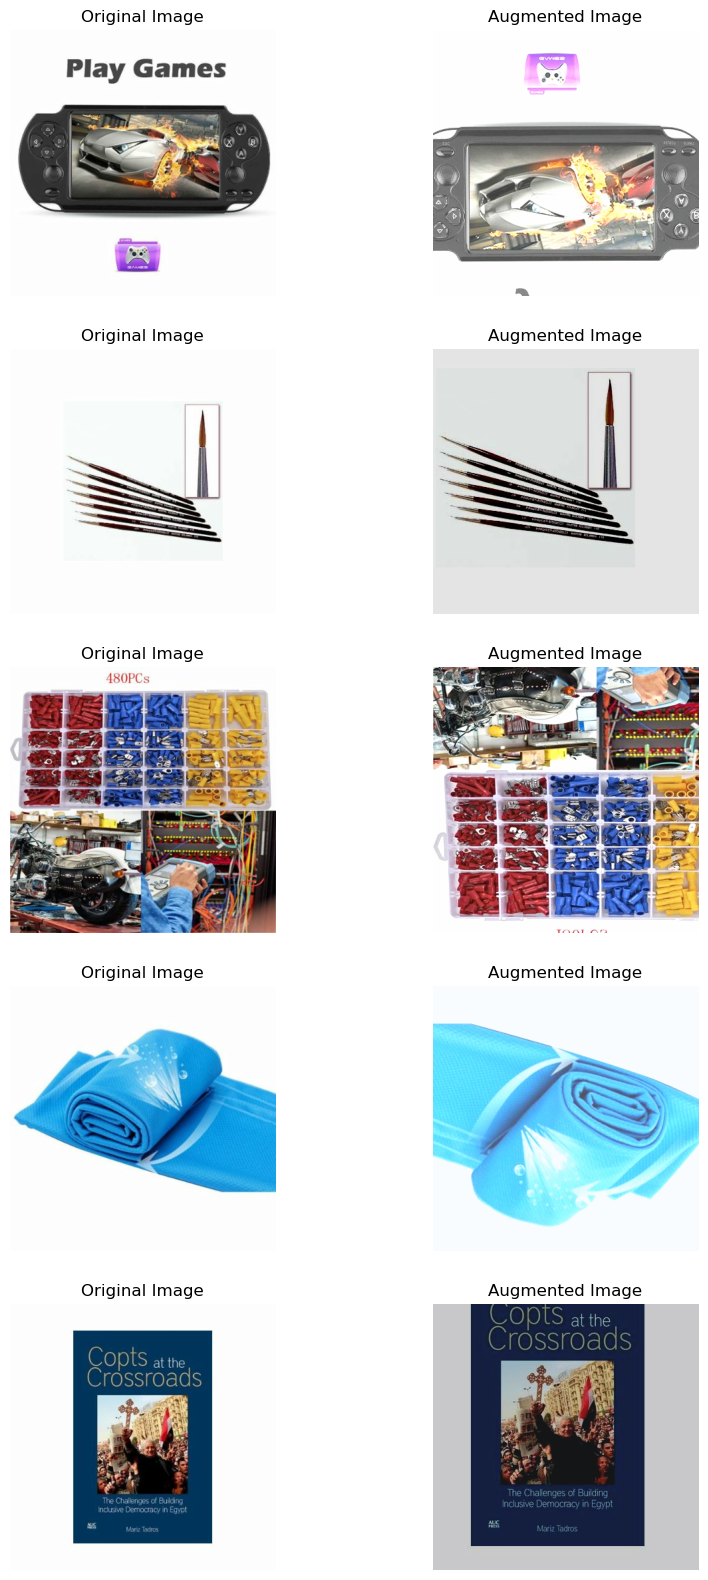

In [22]:
random_samples = X_train_path[:5]

# Créer une figure pour afficher les images
fig, axs = plt.subplots(5, 2, figsize=(10, 20))

for i, nom in enumerate(random_samples):
    print(i, nom)
    # Charger l'image originale
    original_image = load_image(nom)/255.0

    # Redimensionner l'image pour l'affichage
    #resized_image = tf.image.resize(original_image, (IMGSIZE, IMGSIZE))

    # Charger l'image à l'aide de la fonction load_image
    augmented_image = load_and_augment_image(nom)/255.0

    # Afficher l'image originale et l'image augmentée
    axs[i, 0].imshow(original_image)
    axs[i, 0].axis('off')
    axs[i, 0].set_title('Original Image')

    axs[i, 1].imshow(augmented_image)
    axs[i, 1].axis('off')
    axs[i, 1].set_title('Augmented Image')

plt.show()



@tf.function
def load_image(filepath, resize=(500,500)):
    im = tf.io.read_file(filepath)
    im = tf.image.decode_png(im, channels=3)
    return tf.image.resize(im, resize)

dataset_train = tf.data.Dataset.from_tensor_slices((X_train_path, y_train_Network))

dataset_train = dataset_train.map(lambda x, y : [load_image(x),y], num_parallel_calls=-1).batch(32)

dataset_test = tf.data.Dataset.from_tensor_slices((X_test_path, y_test_Network))

dataset_test = dataset_test.map(lambda x, y : [load_image(x),y], num_parallel_calls=-1).batch(32)



In [24]:
#import keras.applications
#help(keras.applications)
"""
PACKAGE CONTENTS
    convnext
    densenet
    efficientnet
    efficientnet_v2
    imagenet_utils
    inception_resnet_v2
    inception_v3
    mobilenet
    mobilenet_v2
    mobilenet_v3
    nasnet
    regnet
    resnet
    resnet_rs
    resnet_v2
    vgg16
    vgg19
    xception
"""

'\nPACKAGE CONTENTS\n    convnext\n    densenet\n    efficientnet\n    efficientnet_v2\n    imagenet_utils\n    inception_resnet_v2\n    inception_v3\n    mobilenet\n    mobilenet_v2\n    mobilenet_v3\n    nasnet\n    regnet\n    resnet\n    resnet_rs\n    resnet_v2\n    vgg16\n    vgg19\n    xception\n'

In [23]:
FREEZE_LAYERS = 15 
from keras.applications.vgg16 import VGG16
#  help(tf.keras.applications)
# Chargement du modèle efficientNet
base_model = VGG16(include_top=False, weights='imagenet',input_shape=(IMGSIZE,IMGSIZE,3))
niv1,niv2 = 0,0
for layer in base_model.layers[:FREEZE_LAYERS]:
    niv1  +=1
    layer.trainable = False
  
# Entrainement des derniers layers de classification
for layer in base_model.layers[FREEZE_LAYERS:]:
    niv2 += 1
    layer.trainable = True
base_model.summary()
print("Nb layers gelées : ",niv1)
print("nb layers dégelées : ", niv2)

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 400, 400, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 400, 400, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 400, 400, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 200, 200, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 200, 200, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 200, 200, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 100, 100, 128)     0     

# II) Activation du meilleur modèle 

### ***************************************************************************
### ***********  FREEZE_LAYERS = 15 JPEG PNG
### ***************************************************************************

In [57]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_5   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_19 (Dropout)        (None, 512)               0         
                                                                 
 dense_27 (Dense)            (None, 1024)              525312    
                                                                 
 batch_normalization_7 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_28 (Dense)            (None, 1024)            

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1249s 542ms/step - loss: 2.9333 - accuracy: 0.2098 - val_loss: 3.5277 - val_accuracy: 0.0104 - lr: 1.0000e-05
Epoch 2/40
 144/2301 [>.............................] - ETA: 16:31 - loss: 3.3370 - accuracy: 0.1278

Epoch 1/40
2301/2301 [==============================] - 1252s 544ms/step - loss: 2.9774 - accuracy: 0.1999 - val_loss: 3.5332 - val_accuracy: 0.0158 - lr: 1.0000e-05
Epoch 2/40
  95/2301 [>.............................] - ETA: 16:47 - loss: 3.7862 - accuracy: 0.0493

In [44]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_5   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_10 (Dropout)        (None, 512)               0         
                                                                 
 dense_15 (Dense)            (None, 1024)              525312    
                                                                 
 batch_normalization_3 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_16 (Dense)            (None, 512)              

Epoch 1/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 3.0044 - accuracy: 0.1463 - val_loss: 3.2087 - val_accuracy: 0.0998 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.6990 - accuracy: 0.2267 - val_loss: 3.2101 - val_accuracy: 0.1104 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.5329 - accuracy: 0.2993 - val_loss: 3.8850 - val_accuracy: 0.0227 - lr: 1.0000e-05
Epoch 4/40
1840/2301 [======================>.......] - ETA: 3:30 - loss: 2.3508 - accuracy: 0.3353

In [35]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_2   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_6 (Dense)             (None, 1024)              525312    
                                                                 
 dropout_4 (Dropout)         (None, 1024)              0         
                                                                 
 dense_7 (Dense)             (None, 1024)              1049600   
                                                                 
 dropout_5 (Dropout)         (None, 1024)              0         
                                                      

Epoch 1/40
2301/2301 [==============================] - 1238s 538ms/step - loss: 2.7438 - accuracy: 0.2586 - val_loss: 7.0881 - val_accuracy: 0.0143 - lr: 1.0000e-05
Epoch 2/40
  30/2301 [..............................] - ETA: 17:18 - loss: 3.7592 - accuracy: 0.0542

In [41]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_4   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_12 (Dense)            (None, 1024)              525312    
                                                                 
 dropout_8 (Dropout)         (None, 1024)              0         
                                                                 
 dense_13 (Dense)            (None, 512)               524800    
                                                                 
 dropout_9 (Dropout)         (None, 512)               0         
                                                      

Epoch 1/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 2.6198 - accuracy: 0.2696 - val_loss: 4.2886 - val_accuracy: 0.0347 - lr: 1.0000e-05
Epoch 2/40
  35/2301 [..............................] - ETA: 17:15 - loss: 3.3075 - accuracy: 0.1080

In [47]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_6   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_18 (Dense)            (None, 1024)              525312    
                                                                 
 dropout_12 (Dropout)        (None, 1024)              0         
                                                                 
 dense_19 (Dense)            (None, 512)               524800    
                                                                 
 dropout_13 (Dropout)        (None, 512)               0         
                                                      

In [42]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten_4 (Flatten)         (None, 73728)             0         
                                                                 
 dropout_10 (Dropout)        (None, 73728)             0         
                                                                 
 dense_15 (Dense)            (None, 1024)              75498496  
                                                                 
 batch_normalization_3 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_16 (Dense)            (None, 1024)              1049600   
                                                      

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1267s 550ms/step - loss: 3.1521 - accuracy: 0.1128 - val_loss: 3.2759 - val_accuracy: 0.0273 - lr: 1.0000e-05
Epoch 2/40
1431/2301 [=================>............] - ETA: 6:46 - loss: 2.9502 - accuracy: 0.1462

In [ ]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(27, activation='softmax'))
model.summary()

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1273s 553ms/step - loss: 2.7056 - accuracy: 0.2833 - val_loss: 3.0511 - val_accuracy: 0.1896 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1268s 551ms/step - loss: 2.2279 - accuracy: 0.3835 - val_loss: 4.0855 - val_accuracy: 0.1505 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1270s 552ms/step - loss: 2.0389 - accuracy: 0.4247 - val_loss: 4.4381 - val_accuracy: 0.1104 - lr: 1.0000e-05
Epoch 4/40
 317/2301 [===>..........................] - ETA: 15:30 - loss: 2.1088 - accuracy: 0.4107

In [35]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten_2 (Flatten)         (None, 73728)             0         
                                                                 
 dropout_6 (Dropout)         (None, 73728)             0         
                                                                 
 dense_9 (Dense)             (None, 1024)              75498496  
                                                                 
 batch_normalization_2 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_10 (Dense)            (None, 512)               524800    
                                                      

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1267s 550ms/step - loss: 2.7874 - accuracy: 0.2905 - val_loss: 3.7324 - val_accuracy: 0.1312 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1268s 551ms/step - loss: 2.3549 - accuracy: 0.3635 - val_loss: 3.8762 - val_accuracy: 0.1215 - lr: 1.0000e-05
Epoch 3/40
  38/2301 [..............................] - ETA: 17:42 - loss: 3.2857 - accuracy: 0.1324

In [ ]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(27, activation='softmax'))
model.summary()

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1267s 550ms/step - loss: 2.7874 - accuracy: 0.2905 - val_loss: 3.7324 - val_accuracy: 0.1312 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1268s 551ms/step - loss: 2.3549 - accuracy: 0.3635 - val_loss: 3.8762 - val_accuracy: 0.1215 - lr: 1.0000e-05
Epoch 3/40
  38/2301 [..............................] - ETA: 17:42 - loss: 3.2857 - accuracy: 0.1324

In [39]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten_3 (Flatten)         (None, 73728)             0         
                                                                 
 dropout_8 (Dropout)         (None, 73728)             0         
                                                                 
 dense_12 (Dense)            (None, 1024)              75498496  
                                                                 
 dropout_9 (Dropout)         (None, 1024)              0         
                                                                 
 dense_13 (Dense)            (None, 512)               524800    
                                                                 
 dense_14 (Dense)            (None, 27)               

In [48]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_2   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_14 (Dropout)        (None, 512)               0         
                                                                 
 dense_21 (Dense)            (None, 1024)              525312    
                                                                 
 batch_normalization_5 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_22 (Dense)            (None, 512)              

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 3.0852 - accuracy: 0.1000 - val_loss: 3.2459 - val_accuracy: 0.0923 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 2.9357 - accuracy: 0.1355 - val_loss: 3.2286 - val_accuracy: 0.0998 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.8369 - accuracy: 0.1640 - val_loss: 3.2161 - val_accuracy: 0.1060 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.7622 - accuracy: 0.1864 - val_loss: 3.1983 - val_accuracy: 0.1170 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.7000 - accuracy: 0.2078 - val_loss: 3.2305 - val_accuracy: 0.1048 - lr: 1.0000e-05
Epoch 6/40
1633/2301 [====================>.........] - ETA: 5:06 - loss: 2.5486 - accuracy: 0.2432

In [52]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.regularizers import l1
from tensorflow.keras.regularizers import l2
regularization_value = 0.001
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu',kernel_regularizer=l2(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l2(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_4   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_17 (Dropout)        (None, 512)               0         
                                                                 
 dense_24 (Dense)            (None, 1024)              525312    
                                                                 
 batch_normalization_6 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_25 (Dense)            (None, 512)              

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1247s 541ms/step - loss: 3.3394 - accuracy: 0.1600 - val_loss: 3.5444 - val_accuracy: 0.1112 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1258s 547ms/step - loss: 2.8817 - accuracy: 0.2448 - val_loss: 5.0676 - val_accuracy: 0.0126 - lr: 1.0000e-05
Epoch 3/40
  16/2301 [..............................] - ETA: 17:27 - loss: 5.1543 - accuracy: 0.0156

In [ ]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1246s 541ms/step - loss: 2.9322 - accuracy: 0.2119 - val_loss: 3.4421 - val_accuracy: 0.0143 - lr: 1.0000e-05
Epoch 2/40
  52/2301 [..............................] - ETA: 17:11 - loss: 4.1354 - accuracy: 0.0264

### ***************************************************************************
### ***********  FREEZE_LAYERS = 15  JPEG JPEG
### ***************************************************************************

In [34]:
FREEZE_LAYERS = 15 
from keras.applications.vgg16 import VGG16
#  help(tf.keras.applications)
# Chargement du modèle efficientNet
base_model = VGG16(include_top=False, weights='imagenet',input_shape=(IMGSIZE,IMGSIZE,3))
niv1,niv2 = 0,0
for layer in base_model.layers[:FREEZE_LAYERS]:
    niv1  +=1
    layer.trainable = False
  
# Entrainement des derniers layers de classification
for layer in base_model.layers[FREEZE_LAYERS:]:
    niv2 += 1
    layer.trainable = True
base_model.summary()
print("Nb layers gelées : ",niv1)
print("nb layers dégelées : ", niv2)

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 400, 400, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 400, 400, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 400, 400, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 200, 200, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 200, 200, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 200, 200, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 100, 100, 128)     0     

In [ ]:
avec Shuffle

In [24]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 1024)              525312    
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 1024)              1

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1218s 528ms/step - loss: 3.1232 - accuracy: 0.1577 - val_loss: 2.2363 - val_accuracy: 0.3667 - lr: 5.0000e-06
Epoch 2/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 2.5575 - accuracy: 0.2767 - val_loss: 2.0288 - val_accuracy: 0.4213 - lr: 5.0000e-06
Epoch 3/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 2.3506 - accuracy: 0.3324 - val_loss: 1.9105 - val_accuracy: 0.4497 - lr: 5.0000e-06
Epoch 4/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.2210 - accuracy: 0.3647 - val_loss: 1.8352 - val_accuracy: 0.4693 - lr: 5.0000e-06
Epoch 5/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 2.1237 - accuracy: 0.3901 - val_loss: 1.7662 - val_accuracy: 0.4867 - lr: 5.0000e-06
Epoch 6/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 2.0464 - accuracy: 0.4080 - val_loss: 1.7210 - val_accuracy: 0.4984 - lr: 5.0000e-06
Epoch 7/40
2301/2301 [==============================] - 1244s 541ms/step - loss: 1.9845 - accuracy: 0.4264 - val_loss: 1.6968 - val_accuracy: 0.5080 - lr: 5.0000e-06
Epoch 8/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.9218 - accuracy: 0.4430 - val_loss: 1.6589 - val_accuracy: 0.5184 - lr: 5.0000e-06
Epoch 9/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 1.8779 - accuracy: 0.4522 - val_loss: 1.6349 - val_accuracy: 0.5227 - lr: 5.0000e-06
Epoch 10/40
2301/2301 [==============================] - 1244s 541ms/step - loss: 1.8370 - accuracy: 0.4650 - val_loss: 1.6081 - val_accuracy: 0.5307 - lr: 5.0000e-06
Epoch 11/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.7956 - accuracy: 0.4741 - val_loss: 1.5770 - val_accuracy: 0.5389 - lr: 5.0000e-06
Epoch 12/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 1.7558 - accuracy: 0.4847 - val_loss: 1.5674 - val_accuracy: 0.5433 - lr: 5.0000e-06
Epoch 13/40
2301/2301 [==============================] - 1244s 541ms/step - loss: 1.7282 - accuracy: 0.4930 - val_loss: 1.5554 - val_accuracy: 0.5455 - lr: 5.0000e-06
Epoch 14/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.6971 - accuracy: 0.4998 - val_loss: 1.5405 - val_accuracy: 0.5497 - lr: 5.0000e-06
Epoch 15/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 1.6614 - accuracy: 0.5111 - val_loss: 1.5210 - val_accuracy: 0.5514 - lr: 5.0000e-06
Epoch 16/40
2301/2301 [==============================] - 1244s 541ms/step - loss: 1.6449 - accuracy: 0.5154 - val_loss: 1.5157 - val_accuracy: 0.5544 - lr: 5.0000e-06
Epoch 17/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 1.6109 - accuracy: 0.5252 - val_loss: 1.4983 - val_accuracy: 0.5574 - lr: 5.0000e-06
Epoch 18/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 1.5882 - accuracy: 0.5312 - val_loss: 1.4995 - val_accuracy: 0.5602 - lr: 5.0000e-06
Epoch 19/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 1.5619 - accuracy: 0.5358 - val_loss: 1.4660 - val_accuracy: 0.5645 - lr: 5.0000e-06
Epoch 20/40
2301/2301 [==============================] - 1239s 539ms/step - loss: 1.5433 - accuracy: 0.5416 - val_loss: 1.4662 - val_accuracy: 0.5641 - lr: 5.0000e-06
Epoch 21/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 1.5187 - accuracy: 0.5470 - val_loss: 1.4550 - val_accuracy: 0.5707 - lr: 5.0000e-06
Epoch 22/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 1.5005 - accuracy: 0.5522 - val_loss: 1.4612 - val_accuracy: 0.5680 - lr: 5.0000e-06
Epoch 23/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 1.4760 - accuracy: 0.5585 - val_loss: 1.4356 - val_accuracy: 0.5760 - lr: 5.0000e-06
Epoch 24/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 1.4526 - accuracy: 0.5648 - val_loss: 1.4300 - val_accuracy: 0.5774 - lr: 5.0000e-06
Epoch 25/40
2301/2301 [==============================] - 1238s 538ms/step - loss: 1.4421 - accuracy: 0.5666 - val_loss: 1.4292 - val_accuracy: 0.5772 - lr: 5.0000e-06
Epoch 26/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 1.4181 - accuracy: 0.5768 - val_loss: 1.4450 - val_accuracy: 0.5734 - lr: 5.0000e-06
Epoch 27/40
2301/2301 [==============================] - ETA: 0s - loss: 1.4009 - accuracy: 0.5783
Epoch 27: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
2301/2301 [==============================] - 1240s 539ms/step - loss: 1.4009 - accuracy: 0.5783 - val_loss: 1.4271 - val_accuracy: 0.5803 - lr: 5.0000e-06
Epoch 28/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 1.3742 - accuracy: 0.5854 - val_loss: 1.4225 - val_accuracy: 0.5796 - lr: 2.5000e-06
Epoch 29/40
2301/2301 [==============================] - 1239s 539ms/step - loss: 1.3605 - accuracy: 0.5903 - val_loss: 1.4025 - val_accuracy: 0.5887 - lr: 2.5000e-06
Epoch 30/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 1.3499 - accuracy: 0.5910 - val_loss: 1.3955 - val_accuracy: 0.5878 - lr: 2.5000e-06
Epoch 31/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 1.3388 - accuracy: 0.5966 - val_loss: 1.4108 - val_accuracy: 0.5840 - lr: 2.5000e-06
Epoch 32/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 1.3299 - accuracy: 0.5955 - val_loss: 1.3910 - val_accuracy: 0.5908 - lr: 2.5000e-06
Epoch 33/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 1.3181 - accuracy: 0.6012 - val_loss: 1.3873 - val_accuracy: 0.5896 - lr: 2.5000e-06
Epoch 34/40
2301/2301 [==============================] - 1245s 541ms/step - loss: 1.3131 - accuracy: 0.6014 - val_loss: 1.3916 - val_accuracy: 0.5885 - lr: 2.5000e-06
Epoch 35/40
2301/2301 [==============================] - 1245s 541ms/step - loss: 1.3033 - accuracy: 0.6048 - val_loss: 1.3887 - val_accuracy: 0.5919 - lr: 2.5000e-06
Epoch 36/40
2301/2301 [==============================] - ETA: 0s - loss: 1.2975 - accuracy: 0.6052
Epoch 36: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.
2301/2301 [==============================] - 1243s 540ms/step - loss: 1.2975 - accuracy: 0.6052 - val_loss: 1.3909 - val_accuracy: 0.5905 - lr: 2.5000e-06
Epoch 37/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.2844 - accuracy: 0.6091 - val_loss: 1.3754 - val_accuracy: 0.5945 - lr: 1.2500e-06
Epoch 38/40
2301/2301 [==============================] - 1248s 542ms/step - loss: 1.2773 - accuracy: 0.6112 - val_loss: 1.3672 - val_accuracy: 0.5958 - lr: 1.2500e-06
Epoch 39/40
2301/2301 [==============================] - 1246s 542ms/step - loss: 1.2723 - accuracy: 0.6126 - val_loss: 1.3832 - val_accuracy: 0.5931 - lr: 1.2500e-06
Epoch 40/40
2301/2301 [==============================] - 1248s 542ms/step - loss: 1.2660 - accuracy: 0.6166 - val_loss: 1.3671 - val_accuracy: 0.5965 - lr: 1.2500e-06


In [60]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_6   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_21 (Dropout)        (None, 512)               0         
                                                                 
 dense_30 (Dense)            (None, 1024)              525312    
                                                                 
 dropout_22 (Dropout)        (None, 1024)              0         
                                                                 
 dense_31 (Dense)            (None, 1024)              1049600   
                                                     

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1242s 539ms/step - loss: 3.0451 - accuracy: 0.1719 - val_loss: 3.2486 - val_accuracy: 0.1594 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 2.5106 - accuracy: 0.2924 - val_loss: 9.6661 - val_accuracy: 0.0134 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 2.3283 - accuracy: 0.3507 - val_loss: 13.7515 - val_accuracy: 0.0124 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - ETA: 0s - loss: 2.1384 - accuracy: 0.3998
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
2301/2301 [==============================] - 1241s 539ms/step - loss: 2.1384 - accuracy: 0.3998 - val_loss: 9.1808 - val_accuracy: 0.0204 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 2.0660 - accuracy: 0.4037 - val_loss: 6.4723 - val_accuracy: 0.0466 - lr: 5.0000e-06
Epoch 6/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.9537 - accuracy: 0.4314 - val_loss: 6.4569 - val_accuracy: 0.0522 - lr: 5.0000e-06
Epoch 7/40
2301/2301 [==============================] - ETA: 0s - loss: 1.8904 - accuracy: 0.4494
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
2301/2301 [==============================] - 1242s 540ms/step - loss: 1.8904 - accuracy: 0.4494 - val_loss: 6.7716 - val_accuracy: 0.0607 - lr: 5.0000e-06
Epoch 8/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.9093 - accuracy: 0.4399 - val_loss: 4.4192 - val_accuracy: 0.1337 - lr: 2.5000e-06
Epoch 9/40
2301/2301 [==============================] - 1256s 546ms/step - loss: 1.8680 - accuracy: 0.4520 - val_loss: 4.4416 - val_accuracy: 0.1346 - lr: 2.5000e-06
Epoch 10/40
2301/2301 [==============================] - ETA: 0s - loss: 1.8446 - accuracy: 0.4560
Epoch 10: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.
2301/2301 [==============================] - 1242s 539ms/step - loss: 1.8446 - accuracy: 0.4560 - val_loss: 4.5257 - val_accuracy: 0.1293 - lr: 2.5000e-06
Epoch 11/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 1.8917 - accuracy: 0.4431 - val_loss: 3.0828 - val_accuracy: 0.2121 - lr: 1.2500e-06
Epoch 12/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8609 - accuracy: 0.4516 - val_loss: 3.1767 - val_accuracy: 0.2028 - lr: 1.2500e-06
Epoch 13/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8431 - accuracy: 0.4557 - val_loss: 3.2118 - val_accuracy: 0.2030 - lr: 1.2500e-06
Epoch 14/40
2301/2301 [==============================] - ETA: 0s - loss: 1.8330 - accuracy: 0.4585
Epoch 14: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-07.
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8330 - accuracy: 0.4585 - val_loss: 3.3279 - val_accuracy: 0.1920 - lr: 1.2500e-06
Epoch 15/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8854 - accuracy: 0.4460 - val_loss: 2.4981 - val_accuracy: 0.2884 - lr: 6.2500e-07
Epoch 16/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8477 - accuracy: 0.4554 - val_loss: 2.5451 - val_accuracy: 0.2823 - lr: 6.2500e-07
Epoch 17/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8389 - accuracy: 0.4589 - val_loss: 2.5559 - val_accuracy: 0.2809 - lr: 6.2500e-07
Epoch 18/40
2301/2301 [==============================] - ETA: 0s - loss: 1.8411 - accuracy: 0.4580
Epoch 18: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-07.
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8411 - accuracy: 0.4580 - val_loss: 2.5717 - val_accuracy: 0.2785 - lr: 6.2500e-07
Epoch 19/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8897 - accuracy: 0.4439 - val_loss: 2.0110 - val_accuracy: 0.4101 - lr: 3.1250e-07
Epoch 20/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8554 - accuracy: 0.4524 - val_loss: 2.0097 - val_accuracy: 0.4109 - lr: 3.1250e-07
Epoch 21/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8409 - accuracy: 0.4571 - val_loss: 2.0039 - val_accuracy: 0.4123 - lr: 3.1250e-07
Epoch 22/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 1.8492 - accuracy: 0.4556 - val_loss: 2.0074 - val_accuracy: 0.4112 - lr: 3.1250e-07
Epoch 23/40
 318/2301 [===>..........................] - ETA: 15:16 - loss: 1.9439 - accuracy: 0.4333

In [28]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 1024)              525312    
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 1024)              1

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1219s 528ms/step - loss: 2.9765 - accuracy: 0.2015 - val_loss: 3.5509 - val_accuracy: 0.0447 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 2.5271 - accuracy: 0.3048 - val_loss: 3.6043 - val_accuracy: 0.0124 - lr: 1.0000e-05
Epoch 3/40
 236/2301 [==>...........................] - ETA: 15:49 - loss: 3.3450 - accuracy: 0.1327

In [31]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_1   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_2 (Dropout)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 1024)              525312    
                                                                 
 dropout_3 (Dropout)         (None, 1024)              0         
                                                                 
 dense_4 (Dense)             (None, 512)               524800    
                                                      

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 2.9251 - accuracy: 0.1728 - val_loss: 3.2498 - val_accuracy: 0.1714 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 2.5151 - accuracy: 0.2882 - val_loss: 3.9244 - val_accuracy: 0.0635 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1238s 538ms/step - loss: 2.2990 - accuracy: 0.3469 - val_loss: 10.5185 - val_accuracy: 0.0262 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - ETA: 0s - loss: 2.1215 - accuracy: 0.4073
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
2301/2301 [==============================] - 1239s 538ms/step - loss: 2.1215 - accuracy: 0.4073 - val_loss: 10.1618 - val_accuracy: 0.0328 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 2.0574 - accuracy: 0.4055 - val_loss: 5.3794 - val_accuracy: 0.1243 - lr: 5.0000e-06
Epoch 6/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 1.9561 - accuracy: 0.4303 - val_loss: 5.5599 - val_accuracy: 0.1330 - lr: 5.0000e-06
Epoch 7/40
2301/2301 [==============================] - ETA: 0s - loss: 1.8958 - accuracy: 0.4471
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
2301/2301 [==============================] - 1241s 539ms/step - loss: 1.8958 - accuracy: 0.4471 - val_loss: 5.8388 - val_accuracy: 0.1280 - lr: 5.0000e-06
Epoch 8/40
2301/2301 [==============================] - 1239s 539ms/step - loss: 1.9144 - accuracy: 0.4392 - val_loss: 3.3234 - val_accuracy: 0.2149 - lr: 2.5000e-06
Epoch 9/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 1.8726 - accuracy: 0.4497 - val_loss: 3.3931 - val_accuracy: 0.2069 - lr: 2.5000e-06
Epoch 10/40
2301/2301 [==============================] - ETA: 0s - loss: 1.8434 - accuracy: 0.4567
Epoch 10: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.
2301/2301 [==============================] - 1243s 540ms/step - loss: 1.8434 - accuracy: 0.4567 - val_loss: 3.4826 - val_accuracy: 0.2004 - lr: 2.5000e-06
Epoch 11/40
  13/2301 [..............................] - ETA: 17:33 - loss: 3.3012 - accuracy: 0.1995

In [42]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_5   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_10 (Dropout)        (None, 512)               0         
                                                                 
 dense_15 (Dense)            (None, 1024)              525312    
                                                                 
 batch_normalization_4 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_16 (Dense)            (None, 1024)             

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1244s 540ms/step - loss: 3.1982 - accuracy: 0.1600 - val_loss: 3.3624 - val_accuracy: 0.0531 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1248s 542ms/step - loss: 2.7045 - accuracy: 0.2644 - val_loss: 3.8390 - val_accuracy: 0.0244 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 2.4962 - accuracy: 0.3100 - val_loss: 3.5835 - val_accuracy: 0.0173 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - ETA: 0s - loss: 2.3829 - accuracy: 0.3371
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.3829 - accuracy: 0.3371 - val_loss: 3.7188 - val_accuracy: 0.0084 - lr: 1.0000e-05
Epoch 5/40
1556/2301 [===================>..........] - ETA: 5:45 - loss: 2.4337 - accuracy: 0.3273

In [43]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(GlobalAveragePooling2D())
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 batch_normalization_5 (Batc  (None, 12, 12, 512)      2048      
 hNormalization)                                                 
                                                                 
 dropout_12 (Dropout)        (None, 12, 12, 512)       0         
                                                                 
 dense_18 (Dense)            (None, 12, 12, 1024)      525312    
                                                                 
 dense_19 (Dense)            (None, 12, 12, 512)       524800    
                                                                 
 dense_20 (Dense)            (None, 12, 12, 256)       131328    
                                                      

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1270s 551ms/step - loss: 2.3382 - accuracy: 0.3495 - val_loss: 3.4679 - val_accuracy: 0.0102 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1264s 549ms/step - loss: 2.3942 - accuracy: 0.3123 - val_loss: 3.6496 - val_accuracy: 0.0128 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1267s 551ms/step - loss: 2.0821 - accuracy: 0.3996 - val_loss: 4.2837 - val_accuracy: 0.0126 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - ETA: 0s - loss: 1.9256 - accuracy: 0.4460
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
2301/2301 [==============================] - 1269s 551ms/step - loss: 1.9256 - accuracy: 0.4460 - val_loss: 4.9592 - val_accuracy: 0.0128 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1268s 551ms/step - loss: 1.9742 - accuracy: 0.4326 - val_loss: 4.0007 - val_accuracy: 0.0447 - lr: 5.0000e-06
Epoch 6/40
2301/2301 [==============================] - 1270s 552ms/step - loss: 1.7965 - accuracy: 0.4818 - val_loss: 4.0707 - val_accuracy: 0.0459 - lr: 5.0000e-06
Epoch 7/40
2301/2301 [==============================] - ETA: 0s - loss: 1.7499 - accuracy: 0.4967
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
2301/2301 [==============================] - 1270s 552ms/step - loss: 1.7499 - accuracy: 0.4967 - val_loss: 4.1897 - val_accuracy: 0.0447 - lr: 5.0000e-06
Epoch 8/40
2301/2301 [==============================] - 1274s 553ms/step - loss: 1.8497 - accuracy: 0.4691 - val_loss: 3.2642 - val_accuracy: 0.1356 - lr: 2.5000e-06
Epoch 9/40
2301/2301 [==============================] - 1273s 553ms/step - loss: 1.6978 - accuracy: 0.5038 - val_loss: 3.5062 - val_accuracy: 0.1334 - lr: 2.5000e-06
Epoch 10/40
2301/2301 [==============================] - 1272s 553ms/step - loss: 1.6613 - accuracy: 0.5136 - val_loss: 3.6381 - val_accuracy: 0.1283 - lr: 2.5000e-06
Epoch 11/40
2301/2301 [==============================] - ETA: 0s - loss: 1.6310 - accuracy: 0.5222
Epoch 11: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.
2301/2301 [==============================] - 1271s 552ms/step - loss: 1.6310 - accuracy: 0.5222 - val_loss: 3.7889 - val_accuracy: 0.1221 - lr: 2.5000e-06
Epoch 12/40
2301/2301 [==============================] - 1270s 552ms/step - loss: 1.6929 - accuracy: 0.5096 - val_loss: 2.4946 - val_accuracy: 0.2982 - lr: 1.2500e-06
Epoch 13/40
2301/2301 [==============================] - 1269s 551ms/step - loss: 1.6510 - accuracy: 0.5199 - val_loss: 2.3999 - val_accuracy: 0.3135 - lr: 1.2500e-06
Epoch 14/40
2301/2301 [==============================] - 1268s 551ms/step - loss: 1.6368 - accuracy: 0.5235 - val_loss: 2.3637 - val_accuracy: 0.3206 - lr: 1.2500e-06
Epoch 15/40
2301/2301 [==============================] - 1265s 550ms/step - loss: 1.6223 - accuracy: 0.5266 - val_loss: 2.3294 - val_accuracy: 0.3296 - lr: 1.2500e-06
Epoch 16/40
2301/2301 [==============================] - 1267s 551ms/step - loss: 1.6104 - accuracy: 0.5290 - val_loss: 2.3223 - val_accuracy: 0.3352 - lr: 1.2500e-06
Epoch 17/40
2301/2301 [==============================] - 1265s 550ms/step - loss: 1.5981 - accuracy: 0.5341 - val_loss: 2.3232 - val_accuracy: 0.3417 - lr: 1.2500e-06
Epoch 18/40
2301/2301 [==============================] - 1269s 551ms/step - loss: 1.5850 - accuracy: 0.5357 - val_loss: 2.3560 - val_accuracy: 0.3407 - lr: 1.2500e-06
Epoch 19/40
2301/2301 [==============================] - ETA: 0s - loss: 1.5733 - accuracy: 0.5391
Epoch 19: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-07.
2301/2301 [==============================] - 1265s 550ms/step - loss: 1.5733 - accuracy: 0.5391 - val_loss: 2.3980 - val_accuracy: 0.3362 - lr: 1.2500e-06
Epoch 20/40
2301/2301 [==============================] - 1266s 550ms/step - loss: 1.6212 - accuracy: 0.5292 - val_loss: 1.9648 - val_accuracy: 0.4543 - lr: 6.2500e-07
Epoch 21/40
2301/2301 [==============================] - 1269s 551ms/step - loss: 1.5939 - accuracy: 0.5387 - val_loss: 1.9616 - val_accuracy: 0.4555 - lr: 6.2500e-07
Epoch 22/40
 547/2301 [======>.......................] - ETA: 13:42 - loss: 1.5850 - accuracy: 0.5455

### ***************************************************************************
### ***********  FREEZE_LAYERS = 18  JPEG JPEG
### ***************************************************************************

In [ ]:
from keras.applications.vgg16 import VGG16
#FREEZE_LAYERS = 18 
base_model = VGG16(include_top=False, weights='imagenet',input_shape=(IMGSIZE,IMGSIZE,3))
niv1,niv2 = 0,0
for layer in base_model.layers[:FREEZE_LAYERS]:
    niv1  +=1
    layer.trainable = False
  
# Entrainement des derniers layers de classification
for layer in base_model.layers[FREEZE_LAYERS:]:
    niv2 += 1
    layer.trainable = True
base_model.summary()
print("Nb layers gelées : ",niv1)
print("nb layers dégelées : ", niv2)

### ***************************************************************************
### ***********  FREEZE_LAYERS = 15  JPEG JPEG RESCAL
### ***************************************************************************

In [28]:
FREEZE_LAYERS = 15 
from keras.applications.vgg16 import VGG16
#  help(tf.keras.applications)
# Chargement du modèle efficientNet
base_model = VGG16(include_top=False, weights='imagenet',input_shape=(IMGSIZE,IMGSIZE,3))
niv1,niv2 = 0,0
for layer in base_model.layers[:FREEZE_LAYERS]:
    niv1  +=1
    layer.trainable = False
  
# Entrainement des derniers layers de classification
for layer in base_model.layers[FREEZE_LAYERS:]:
    niv2 += 1
    layer.trainable = True
base_model.summary()
print("Nb layers gelées : ",niv1)
print("nb layers dégelées : ", niv2)

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 400, 400, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 400, 400, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 400, 400, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 200, 200, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 200, 200, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 200, 200, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 100, 100, 128)     0     

In [ ]:
Avec Shuffle

In [29]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(1024, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

In [28]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(1024, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1247s 541ms/step - loss: 2.8684 - accuracy: 0.2048 - val_loss: 3.3083 - val_accuracy: 0.0388 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1242s 540ms/step - loss: 2.4463 - accuracy: 0.3107 - val_loss: 3.2707 - val_accuracy: 0.0714 - lr: 1.0000e-05
Epoch 3/40
1827/2301 [======================>.......] - ETA: 3:37 - loss: 2.1989 - accuracy: 0.3647

In [31]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.6767 - accuracy: 0.2371 - val_loss: 3.2117 - val_accuracy: 0.0713 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.3061 - accuracy: 0.3391 - val_loss: 10.6871 - val_accuracy: 0.0109 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.1368 - accuracy: 0.3857 - val_loss: 10.0529 - val_accuracy: 0.0110 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - ETA: 0s - loss: 2.0251 - accuracy: 0.4139
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
2301/2301 [==============================] - 1244s 541ms/step - loss: 2.0251 - accuracy: 0.4139 - val_loss: 9.9455 - val_accuracy: 0.0112 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1245s 541ms/step - loss: 2.0062 - accuracy: 0.4129 - val_loss: 5.9022 - val_accuracy: 0.0175 - lr: 5.0000e-06
Epoch 6/40
2301/2301 [==============================] - 1260s 547ms/step - loss: 1.9169 - accuracy: 0.4326 - val_loss: 6.1886 - val_accuracy: 0.0155 - lr: 5.0000e-06
Epoch 7/40
2301/2301 [==============================] - ETA: 0s - loss: 1.8739 - accuracy: 0.4452
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
2301/2301 [==============================] - 1247s 542ms/step - loss: 1.8739 - accuracy: 0.4452 - val_loss: 6.1752 - val_accuracy: 0.0153 - lr: 5.0000e-06
Epoch 8/40
2058/2301 [=========================>....] - ETA: 1:51 - loss: 1.9702 - accuracy: 0.4178

In [34]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    Flatten(),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1271s 552ms/step - loss: 2.0313 - accuracy: 0.4369 - val_loss: 7.6752 - val_accuracy: 0.0232 - lr: 1.0000e-05
Epoch 2/40
  76/2301 [..............................] - ETA: 17:23 - loss: 2.7545 - accuracy: 0.2652

In [37]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    Flatten(),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1269s 551ms/step - loss: 1.9710 - accuracy: 0.4461 - val_loss: 9.3837 - val_accuracy: 0.0189 - lr: 1.0000e-05
Epoch 2/40
  38/2301 [..............................] - ETA: 17:46 - loss: 3.3092 - accuracy: 0.1982

In [40]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    Flatten(),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1269s 551ms/step - loss: 2.3322 - accuracy: 0.3625 - val_loss: 8.7881 - val_accuracy: 0.0186 - lr: 1.0000e-05
Epoch 2/40
  69/2301 [..............................] - ETA: 17:26 - loss: 2.9155 - accuracy: 0.2527

In [43]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    Flatten(),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1268s 551ms/step - loss: 1.7907 - accuracy: 0.4949 - val_loss: 8.1584 - val_accuracy: 0.0180 - lr: 1.0000e-05
Epoch 2/40
  75/2301 [..............................] - ETA: 17:26 - loss: 2.7901 - accuracy: 0.2546


In [46]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    Flatten(),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1271s 552ms/step - loss: 2.2347 - accuracy: 0.4054 - val_loss: 10.1197 - val_accuracy: 0.0207 - lr: 1.0000e-05
Epoch 2/40
 102/2301 [>.............................] - ETA: 17:13 - loss: 2.7534 - accuracy: 0.3015

In [49]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1258s 546ms/step - loss: 2.2065 - accuracy: 0.4093 - val_loss: 10.6356 - val_accuracy: 0.0190 - lr: 1.0000e-05
Epoch 2/40
 178/2301 [=>............................] - ETA: 16:23 - loss: 2.4078 - accuracy: 0.3724

In [52]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1246s 541ms/step - loss: 2.6999 - accuracy: 0.2492 - val_loss: 3.2289 - val_accuracy: 0.1269 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1245s 541ms/step - loss: 2.3075 - accuracy: 0.3444 - val_loss: 3.2271 - val_accuracy: 0.1298 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1246s 541ms/step - loss: 2.1894 - accuracy: 0.3754 - val_loss: 3.2401 - val_accuracy: 0.0546 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.0914 - accuracy: 0.4102 - val_loss: 3.3658 - val_accuracy: 0.0196 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - ETA: 0s - loss: 2.0261 - accuracy: 0.4294
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
2301/2301 [==============================] - 1247s 542ms/step - loss: 2.0261 - accuracy: 0.4294 - val_loss: 3.4698 - val_accuracy: 0.0191 - lr: 1.0000e-05
Epoch 6/40
  20/2301 [..............................] - ETA: 17:34 - loss: 4.3587 - accuracy: 0.0328


### ***************************************************************************
### ***********  FREEZE_LAYERS = 18  JPEG JPEG RESCAL
### ***************************************************************************

In [55]:
from keras.applications.vgg16 import VGG16
FREEZE_LAYERS = 18 
base_model = VGG16(include_top=False, weights='imagenet',input_shape=(IMGSIZE,IMGSIZE,3))
niv1,niv2 = 0,0
for layer in base_model.layers[:FREEZE_LAYERS]:
    niv1  +=1
    layer.trainable = False
  
# Entrainement des derniers layers de classification
for layer in base_model.layers[FREEZE_LAYERS:]:
    niv2 += 1
    layer.trainable = True
base_model.summary()
print("Nb layers gelées : ",niv1)
print("nb layers dégelées : ", niv2)

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 400, 400, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 400, 400, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 400, 400, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 200, 200, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 200, 200, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 200, 200, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 100, 100, 128)     0     

In [34]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(1024, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])
#model.summary()

Epoch 1/40
2301/2301 [==============================] - 1067s 463ms/step - loss: 3.3567 - accuracy: 0.0852 - val_loss: 2.9640 - val_accuracy: 0.1621 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 3.0972 - accuracy: 0.1350 - val_loss: 2.7704 - val_accuracy: 0.2458 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.9706 - accuracy: 0.1651 - val_loss: 2.6489 - val_accuracy: 0.2866 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.8901 - accuracy: 0.1849 - val_loss: 2.5643 - val_accuracy: 0.3140 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.8262 - accuracy: 0.2034 - val_loss: 2.5087 - val_accuracy: 0.3242 - lr: 1.0000e-05
Epoch 6/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.7859 - accuracy: 0.2127 - val_loss: 2.4594 - val_accuracy: 0.3352 - lr: 1.0000e-05
Epoch 7/40
2301/2301 [==============================] - 1094s 475ms/step - loss: 2.7487 - accuracy: 0.2224 - val_loss: 2.4270 - val_accuracy: 0.3404 - lr: 1.0000e-05
Epoch 8/40
2301/2301 [==============================] - 1090s 473ms/step - loss: 2.7196 - accuracy: 0.2317 - val_loss: 2.3920 - val_accuracy: 0.3458 - lr: 1.0000e-05
Epoch 9/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.6950 - accuracy: 0.2338 - val_loss: 2.3699 - val_accuracy: 0.3490 - lr: 1.0000e-05
Epoch 10/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.6740 - accuracy: 0.2409 - val_loss: 2.3480 - val_accuracy: 0.3551 - lr: 1.0000e-05
Epoch 11/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.6538 - accuracy: 0.2476 - val_loss: 2.3248 - val_accuracy: 0.3597 - lr: 1.0000e-05
Epoch 12/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.6348 - accuracy: 0.2524 - val_loss: 2.3068 - val_accuracy: 0.3639 - lr: 1.0000e-05
Epoch 13/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.6251 - accuracy: 0.2530 - val_loss: 2.2972 - val_accuracy: 0.3645 - lr: 1.0000e-05
Epoch 14/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.5996 - accuracy: 0.2601 - val_loss: 2.2823 - val_accuracy: 0.3687 - lr: 1.0000e-05
Epoch 15/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.5906 - accuracy: 0.2627 - val_loss: 2.2626 - val_accuracy: 0.3752 - lr: 1.0000e-05
Epoch 16/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.5737 - accuracy: 0.2650 - val_loss: 2.2547 - val_accuracy: 0.3759 - lr: 1.0000e-05
Epoch 17/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.5602 - accuracy: 0.2681 - val_loss: 2.2498 - val_accuracy: 0.3743 - lr: 1.0000e-05
Epoch 18/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.5492 - accuracy: 0.2703 - val_loss: 2.2396 - val_accuracy: 0.3781 - lr: 1.0000e-05
Epoch 19/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.5474 - accuracy: 0.2742 - val_loss: 2.2344 - val_accuracy: 0.3801 - lr: 1.0000e-05
Epoch 20/40
2301/2301 [==============================] - 1104s 480ms/step - loss: 2.5329 - accuracy: 0.2751 - val_loss: 2.2205 - val_accuracy: 0.3879 - lr: 1.0000e-05
Epoch 21/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.5199 - accuracy: 0.2797 - val_loss: 2.2095 - val_accuracy: 0.3902 - lr: 1.0000e-05
Epoch 22/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.5115 - accuracy: 0.2831 - val_loss: 2.2083 - val_accuracy: 0.3885 - lr: 1.0000e-05
Epoch 23/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.4997 - accuracy: 0.2859 - val_loss: 2.1994 - val_accuracy: 0.3930 - lr: 1.0000e-05
Epoch 24/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.4945 - accuracy: 0.2857 - val_loss: 2.1960 - val_accuracy: 0.3923 - lr: 1.0000e-05
Epoch 25/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.4843 - accuracy: 0.2890 - val_loss: 2.1857 - val_accuracy: 0.3940 - lr: 1.0000e-05
Epoch 26/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.4765 - accuracy: 0.2908 - val_loss: 2.1764 - val_accuracy: 0.3962 - lr: 1.0000e-05
Epoch 27/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.4671 - accuracy: 0.2923 - val_loss: 2.1788 - val_accuracy: 0.3984 - lr: 1.0000e-05
Epoch 28/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.4609 - accuracy: 0.2928 - val_loss: 2.1741 - val_accuracy: 0.4004 - lr: 1.0000e-05
Epoch 29/40
2301/2301 [==============================] - 1104s 480ms/step - loss: 2.4584 - accuracy: 0.2934 - val_loss: 2.1712 - val_accuracy: 0.4011 - lr: 1.0000e-05
Epoch 30/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.4473 - accuracy: 0.2985 - val_loss: 2.1649 - val_accuracy: 0.4026 - lr: 1.0000e-05
Epoch 31/40
2301/2301 [==============================] - 1090s 473ms/step - loss: 2.4384 - accuracy: 0.2963 - val_loss: 2.1621 - val_accuracy: 0.4034 - lr: 1.0000e-05
Epoch 32/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.4319 - accuracy: 0.3002 - val_loss: 2.1544 - val_accuracy: 0.4046 - lr: 1.0000e-05
Epoch 33/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.4285 - accuracy: 0.3018 - val_loss: 2.1562 - val_accuracy: 0.4065 - lr: 1.0000e-05
Epoch 34/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.4150 - accuracy: 0.3035 - val_loss: 2.1491 - val_accuracy: 0.4065 - lr: 1.0000e-05
Epoch 35/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.4174 - accuracy: 0.3054 - val_loss: 2.1475 - val_accuracy: 0.4077 - lr: 1.0000e-05
Epoch 36/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.4075 - accuracy: 0.3057 - val_loss: 2.1498 - val_accuracy: 0.4080 - lr: 1.0000e-05
Epoch 37/40
2301/2301 [==============================] - 1090s 473ms/step - loss: 2.4012 - accuracy: 0.3056 - val_loss: 2.1472 - val_accuracy: 0.4106 - lr: 1.0000e-05
Epoch 38/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.3938 - accuracy: 0.3084 - val_loss: 2.1442 - val_accuracy: 0.4113 - lr: 1.0000e-05
Epoch 39/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.3925 - accuracy: 0.3083 - val_loss: 2.1407 - val_accuracy: 0.4119 - lr: 1.0000e-05
Epoch 40/40
2301/2301 [==============================] - 1090s 473ms/step - loss: 2.3851 - accuracy: 0.3117 - val_loss: 2.1395 - val_accuracy: 0.4109 - lr: 1.0000e-05

In [23]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1085s 470ms/step - loss: 3.1550 - accuracy: 0.0950 - val_loss: 3.6430 - val_accuracy: 0.0192 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 3.0434 - accuracy: 0.1338 - val_loss: 3.4971 - val_accuracy: 0.0232 - lr: 1.0000e-05
Epoch 3/40
 859/2301 [==========>...................] - ETA: 9:28 - loss: 2.9821 - accuracy: 0.1420

In [56]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1094s 475ms/step - loss: 3.4741 - accuracy: 0.0754 - val_loss: 2.9890 - val_accuracy: 0.1898 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 3.1763 - accuracy: 0.1202 - val_loss: 2.8109 - val_accuracy: 0.2498 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 3.0391 - accuracy: 0.1507 - val_loss: 2.6969 - val_accuracy: 0.2780 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.9480 - accuracy: 0.1717 - val_loss: 2.6153 - val_accuracy: 0.3000 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.8821 - accuracy: 0.1867 - val_loss: 2.5563 - val_accuracy: 0.3105 - lr: 1.0000e-05
Epoch 6/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.8383 - accuracy: 0.1967 - val_loss: 2.5087 - val_accuracy: 0.3221 - lr: 1.0000e-05
Epoch 7/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.8032 - accuracy: 0.2054 - val_loss: 2.4713 - val_accuracy: 0.3267 - lr: 1.0000e-05
Epoch 8/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.7675 - accuracy: 0.2130 - val_loss: 2.4356 - val_accuracy: 0.3361 - lr: 1.0000e-05
Epoch 9/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.7492 - accuracy: 0.2177 - val_loss: 2.4049 - val_accuracy: 0.3446 - lr: 1.0000e-05
Epoch 10/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.7174 - accuracy: 0.2277 - val_loss: 2.3789 - val_accuracy: 0.3515 - lr: 1.0000e-05
Epoch 11/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.6988 - accuracy: 0.2303 - val_loss: 2.3560 - val_accuracy: 0.3585 - lr: 1.0000e-05
Epoch 12/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.6804 - accuracy: 0.2343 - val_loss: 2.3368 - val_accuracy: 0.3638 - lr: 1.0000e-05
Epoch 13/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.6606 - accuracy: 0.2396 - val_loss: 2.3108 - val_accuracy: 0.3701 - lr: 1.0000e-05
Epoch 14/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.6437 - accuracy: 0.2436 - val_loss: 2.2986 - val_accuracy: 0.3724 - lr: 1.0000e-05
Epoch 15/40
2301/2301 [==============================] - 1090s 473ms/step - loss: 2.6331 - accuracy: 0.2495 - val_loss: 2.2816 - val_accuracy: 0.3800 - lr: 1.0000e-05
Epoch 16/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.6137 - accuracy: 0.2520 - val_loss: 2.2660 - val_accuracy: 0.3810 - lr: 1.0000e-05
Epoch 17/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.6029 - accuracy: 0.2536 - val_loss: 2.2602 - val_accuracy: 0.3820 - lr: 1.0000e-05
Epoch 18/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.5901 - accuracy: 0.2570 - val_loss: 2.2448 - val_accuracy: 0.3872 - lr: 1.0000e-05
Epoch 19/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.5822 - accuracy: 0.2595 - val_loss: 2.2308 - val_accuracy: 0.3889 - lr: 1.0000e-05
Epoch 20/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.5685 - accuracy: 0.2630 - val_loss: 2.2228 - val_accuracy: 0.3918 - lr: 1.0000e-05
Epoch 21/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.5571 - accuracy: 0.2652 - val_loss: 2.2106 - val_accuracy: 0.3936 - lr: 1.0000e-05
Epoch 22/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.5497 - accuracy: 0.2687 - val_loss: 2.2030 - val_accuracy: 0.3958 - lr: 1.0000e-05
Epoch 23/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.5451 - accuracy: 0.2684 - val_loss: 2.1976 - val_accuracy: 0.3966 - lr: 1.0000e-05
Epoch 24/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.5355 - accuracy: 0.2703 - val_loss: 2.1887 - val_accuracy: 0.3975 - lr: 1.0000e-05
Epoch 25/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.5256 - accuracy: 0.2724 - val_loss: 2.1827 - val_accuracy: 0.4006 - lr: 1.0000e-05
Epoch 26/40
2301/2301 [==============================] - 1094s 476ms/step - loss: 2.5130 - accuracy: 0.2764 - val_loss: 2.1780 - val_accuracy: 0.4002 - lr: 1.0000e-05
Epoch 27/40
2301/2301 [==============================] - 1094s 475ms/step - loss: 2.5066 - accuracy: 0.2770 - val_loss: 2.1739 - val_accuracy: 0.4009 - lr: 1.0000e-05
Epoch 28/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.5043 - accuracy: 0.2793 - val_loss: 2.1659 - val_accuracy: 0.4029 - lr: 1.0000e-05
Epoch 29/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.4921 - accuracy: 0.2818 - val_loss: 2.1576 - val_accuracy: 0.4033 - lr: 1.0000e-05
Epoch 30/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.4857 - accuracy: 0.2828 - val_loss: 2.1542 - val_accuracy: 0.4024 - lr: 1.0000e-05
Epoch 31/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.4803 - accuracy: 0.2837 - val_loss: 2.1533 - val_accuracy: 0.4046 - lr: 1.0000e-05
Epoch 32/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.4714 - accuracy: 0.2841 - val_loss: 2.1461 - val_accuracy: 0.4064 - lr: 1.0000e-05
Epoch 33/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.4744 - accuracy: 0.2849 - val_loss: 2.1429 - val_accuracy: 0.4083 - lr: 1.0000e-05
Epoch 34/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.4602 - accuracy: 0.2880 - val_loss: 2.1381 - val_accuracy: 0.4075 - lr: 1.0000e-05
Epoch 35/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.4605 - accuracy: 0.2870 - val_loss: 2.1380 - val_accuracy: 0.4095 - lr: 1.0000e-05
Epoch 36/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.4489 - accuracy: 0.2914 - val_loss: 2.1331 - val_accuracy: 0.4096 - lr: 1.0000e-05
Epoch 37/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.4510 - accuracy: 0.2902 - val_loss: 2.1317 - val_accuracy: 0.4129 - lr: 1.0000e-05
Epoch 38/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.4355 - accuracy: 0.2936 - val_loss: 2.1326 - val_accuracy: 0.4129 - lr: 1.0000e-05
Epoch 39/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.4417 - accuracy: 0.2929 - val_loss: 2.1280 - val_accuracy: 0.4128 - lr: 1.0000e-05
Epoch 40/40
2301/2301 [==============================] - 1102s 479ms/step - loss: 2.4232 - accuracy: 0.2964 - val_loss: 2.1198 - val_accuracy: 0.4154 - lr: 1.0000e-05

### ***************************************************************************
### ***********  FREEZE_LAYERS = 18 JPEG PNG
### ***************************************************************************

In [21]:
from keras.applications.vgg16 import VGG16
FREEZE_LAYERS = 18 
base_model = VGG16(include_top=False, weights='imagenet',input_shape=(IMGSIZE,IMGSIZE,3))
niv1,niv2 = 0,0
for layer in base_model.layers[:FREEZE_LAYERS]:
    niv1  +=1
    layer.trainable = False
  
# Entrainement des derniers layers de classification
for layer in base_model.layers[FREEZE_LAYERS:]:
    niv2 += 1
    layer.trainable = True
base_model.summary()
print("Nb layers gelées : ",niv1)
print("nb layers dégelées : ", niv2)

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 400, 400, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 400, 400, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 400, 400, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 200, 200, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 200, 200, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 200, 200, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 100, 100, 128)     0     

In [22]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten (Flatten)           (None, 73728)             0         
                                                                 
 dropout (Dropout)           (None, 73728)             0         
                                                                 
 dense (Dense)               (None, 1024)              75498496  
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 1024)              1049600   
                                                        

Epoch 1/40
2301/2301 [==============================] - 1111s 482ms/step - loss: 2.8448 - accuracy: 0.2569 - val_loss: 2.0844 - val_accuracy: 0.4157 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1109s 482ms/step - loss: 2.4100 - accuracy: 0.3463 - val_loss: 1.9754 - val_accuracy: 0.4367 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 2.2377 - accuracy: 0.3855 - val_loss: 1.9602 - val_accuracy: 0.4427 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 2.1108 - accuracy: 0.4127 - val_loss: 1.9387 - val_accuracy: 0.4539 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1106s 481ms/step - loss: 2.0177 - accuracy: 0.4327 - val_loss: 1.9583 - val_accuracy: 0.4502 - lr: 1.0000e-05
Epoch 6/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 1.9386 - accuracy: 0.4504 - val_loss: 1.9510 - val_accuracy: 0.4521 - lr: 1.0000e-05
Epoch 7/40
2301/2301 [==============================] - 1118s 486ms/step - loss: 1.8633 - accuracy: 0.4682 - val_loss: 1.9581 - val_accuracy: 0.4507 - lr: 1.0000e-05
Epoch 8/40
1510/2301 [==================>...........] - ETA: 5:18 - loss: 1.7241 - accuracy: 0.4987

In [57]:
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.regularizers import l1
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l2(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten_1 (Flatten)         (None, 73728)             0         
                                                                 
 dropout_19 (Dropout)        (None, 73728)             0         
                                                                 
 dense_28 (Dense)            (None, 1024)              75498496  
                                                                 
 batch_normalization_5 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_29 (Dense)            (None, 512)               524800    
                                                      

Epoch 1/40
2301/2301 [==============================] - 1115s 484ms/step - loss: 3.0032 - accuracy: 0.2417 - val_loss: 2.0484 - val_accuracy: 0.4262 - lr: 1.0000e-05
Epoch 2/40
 169/2301 [=>............................] - ETA: 14:18 - loss: 2.5101 - accuracy: 0.3108

In [60]:
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.regularizers import l1
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l2(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten_2 (Flatten)         (None, 73728)             0         
                                                                 
 dropout_21 (Dropout)        (None, 73728)             0         
                                                                 
 dense_31 (Dense)            (None, 1024)              75498496  
                                                                 
 batch_normalization_6 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_32 (Dense)            (None, 512)               524800    
                                                     

Epoch 1/40
2301/2301 [==============================] - 1109s 482ms/step - loss: 3.2161 - accuracy: 0.1733 - val_loss: 2.3493 - val_accuracy: 0.3943 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1108s 482ms/step - loss: 2.7271 - accuracy: 0.2629 - val_loss: 2.1525 - val_accuracy: 0.4371 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 2.5346 - accuracy: 0.3044 - val_loss: 2.0509 - val_accuracy: 0.4547 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1106s 481ms/step - loss: 2.4129 - accuracy: 0.3305 - val_loss: 1.9786 - val_accuracy: 0.4656 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 2.3259 - accuracy: 0.3538 - val_loss: 1.9329 - val_accuracy: 0.4737 - lr: 1.0000e-05
Epoch 6/40
2301/2301 [==============================] - 1106s 481ms/step - loss: 2.2577 - accuracy: 0.3674 - val_loss: 1.9004 - val_accuracy: 0.4756 - lr: 1.0000e-05
Epoch 7/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 2.2048 - accuracy: 0.3812 - val_loss: 1.8679 - val_accuracy: 0.4818 - lr: 1.0000e-05
Epoch 8/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 2.1499 - accuracy: 0.3934 - val_loss: 1.8477 - val_accuracy: 0.4826 - lr: 1.0000e-05
Epoch 9/40
2301/2301 [==============================] - 1106s 481ms/step - loss: 2.1037 - accuracy: 0.4036 - val_loss: 1.8257 - val_accuracy: 0.4871 - lr: 1.0000e-05
Epoch 10/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 2.0669 - accuracy: 0.4144 - val_loss: 1.8126 - val_accuracy: 0.4869 - lr: 1.0000e-05
Epoch 11/40
2301/2301 [==============================] - 1106s 481ms/step - loss: 2.0296 - accuracy: 0.4218 - val_loss: 1.7998 - val_accuracy: 0.4908 - lr: 1.0000e-05
Epoch 12/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.9971 - accuracy: 0.4308 - val_loss: 1.7851 - val_accuracy: 0.4937 - lr: 1.0000e-05
Epoch 13/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.9614 - accuracy: 0.4389 - val_loss: 1.7694 - val_accuracy: 0.4969 - lr: 1.0000e-05
Epoch 14/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.9403 - accuracy: 0.4450 - val_loss: 1.7554 - val_accuracy: 0.4986 - lr: 1.0000e-05
Epoch 15/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.9151 - accuracy: 0.4516 - val_loss: 1.7449 - val_accuracy: 0.5021 - lr: 1.0000e-05
Epoch 16/40
2301/2301 [==============================] - 1106s 481ms/step - loss: 1.8833 - accuracy: 0.4579 - val_loss: 1.7415 - val_accuracy: 0.5037 - lr: 1.0000e-05
Epoch 17/40
2301/2301 [==============================] - 1106s 481ms/step - loss: 1.8635 - accuracy: 0.4643 - val_loss: 1.7272 - val_accuracy: 0.5005 - lr: 1.0000e-05
Epoch 18/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.8374 - accuracy: 0.4705 - val_loss: 1.7209 - val_accuracy: 0.5019 - lr: 1.0000e-05
Epoch 19/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.8081 - accuracy: 0.4765 - val_loss: 1.7221 - val_accuracy: 0.5024 - lr: 1.0000e-05
Epoch 20/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.7963 - accuracy: 0.4801 - val_loss: 1.7195 - val_accuracy: 0.5011 - lr: 1.0000e-05
Epoch 21/40
2301/2301 [==============================] - 1108s 481ms/step - loss: 1.7754 - accuracy: 0.4846 - val_loss: 1.7080 - val_accuracy: 0.5060 - lr: 1.0000e-05
Epoch 22/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.7527 - accuracy: 0.4906 - val_loss: 1.7061 - val_accuracy: 0.5061 - lr: 1.0000e-05
Epoch 23/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.7359 - accuracy: 0.4979 - val_loss: 1.6965 - val_accuracy: 0.5060 - lr: 1.0000e-05
Epoch 24/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.7198 - accuracy: 0.5015 - val_loss: 1.6989 - val_accuracy: 0.5050 - lr: 1.0000e-05
Epoch 25/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 1.6978 - accuracy: 0.5066 - val_loss: 1.6889 - val_accuracy: 0.5074 - lr: 1.0000e-05
Epoch 26/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 1.6831 - accuracy: 0.5090 - val_loss: 1.6763 - val_accuracy: 0.5079 - lr: 1.0000e-05
Epoch 27/40
 264/2301 [==>...........................] - ETA: 13:35 - loss: 1.7346 - accuracy: 0.5001

In [64]:
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_8   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_24 (Dropout)        (None, 512)               0         
                                                                 
 dense_35 (Dense)            (None, 1024)              525312    
                                                                 
 batch_normalization_7 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_36 (Dense)            (None, 1024)            

Epoch 1/40
2301/2301 [==============================] - 1088s 472ms/step - loss: 3.2461 - accuracy: 0.1484 - val_loss: 2.4020 - val_accuracy: 0.3660 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1086s 472ms/step - loss: 2.8573 - accuracy: 0.2241 - val_loss: 2.2124 - val_accuracy: 0.4009 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1087s 472ms/step - loss: 2.7227 - accuracy: 0.2549 - val_loss: 2.1182 - val_accuracy: 0.4152 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1087s 472ms/step - loss: 2.6345 - accuracy: 0.2748 - val_loss: 2.0605 - val_accuracy: 0.4234 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1087s 473ms/step - loss: 2.5809 - accuracy: 0.2846 - val_loss: 2.0170 - val_accuracy: 0.4303 - lr: 1.0000e-05
Epoch 6/40
2301/2301 [==============================] - 1087s 473ms/step - loss: 2.5278 - accuracy: 0.2957 - val_loss: 1.9906 - val_accuracy: 0.4325 - lr: 1.0000e-05
Epoch 7/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.4820 - accuracy: 0.3052 - val_loss: 1.9727 - val_accuracy: 0.4398 - lr: 1.0000e-05
Epoch 8/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.4488 - accuracy: 0.3124 - val_loss: 1.9504 - val_accuracy: 0.4447 - lr: 1.0000e-05
Epoch 9/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.4132 - accuracy: 0.3193 - val_loss: 1.9369 - val_accuracy: 0.4479 - lr: 1.0000e-05
Epoch 10/40
2301/2301 [==============================] - 1087s 473ms/step - loss: 2.3897 - accuracy: 0.3235 - val_loss: 1.9247 - val_accuracy: 0.4534 - lr: 1.0000e-05
Epoch 11/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.3660 - accuracy: 0.3311 - val_loss: 1.9124 - val_accuracy: 0.4555 - lr: 1.0000e-05
Epoch 12/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.3385 - accuracy: 0.3344 - val_loss: 1.9064 - val_accuracy: 0.4572 - lr: 1.0000e-05
Epoch 13/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.3223 - accuracy: 0.3380 - val_loss: 1.8936 - val_accuracy: 0.4621 - lr: 1.0000e-05
Epoch 14/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.2927 - accuracy: 0.3435 - val_loss: 1.8951 - val_accuracy: 0.4611 - lr: 1.0000e-05
Epoch 15/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.2727 - accuracy: 0.3509 - val_loss: 1.8784 - val_accuracy: 0.4676 - lr: 1.0000e-05
Epoch 16/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.2540 - accuracy: 0.3518 - val_loss: 1.8782 - val_accuracy: 0.4675 - lr: 1.0000e-05
Epoch 17/40
2236/2301 [============================>.] - ETA: 25s - loss: 2.2148 - accuracy: 0.3615

In [68]:
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_9   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_26 (Dropout)        (None, 512)               0         
                                                                 
 dense_38 (Dense)            (None, 1024)              525312    
                                                                 
 dropout_27 (Dropout)        (None, 1024)              0         
                                                                 
 dense_39 (Dense)            (None, 1024)              1049600   
                                                     

Epoch 1/40
2301/2301 [==============================] - 1088s 472ms/step - loss: 3.7174 - accuracy: 0.1797 - val_loss: 4.6774 - val_accuracy: 0.0275 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.8959 - accuracy: 0.2427 - val_loss: 3.6948 - val_accuracy: 0.0609 - lr: 1.0000e-05
Epoch 3/40
1946/2301 [========================>.....] - ETA: 2:19 - loss: 2.6927 - accuracy: 0.2536

In [72]:
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten_3 (Flatten)         (None, 73728)             0         
                                                                 
 dropout_28 (Dropout)        (None, 73728)             0         
                                                                 
 dense_41 (Dense)            (None, 1024)              75498496  
                                                                 
 dropout_29 (Dropout)        (None, 1024)              0         
                                                                 
 dense_42 (Dense)            (None, 1024)              1049600   
                                                                 
 dense_43 (Dense)            (None, 27)              

Epoch 1/40
2301/2301 [==============================] - 1108s 481ms/step - loss: 5.7350 - accuracy: 0.1756 - val_loss: 3.7003 - val_accuracy: 0.0453 - lr: 1.0000e-05
Epoch 2/40
 272/2301 [==>...........................] - ETA: 13:35 - loss: 3.2731 - accuracy: 0.1410

In [76]:
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l2(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten_4 (Flatten)         (None, 73728)             0         
                                                                 
 dropout_30 (Dropout)        (None, 73728)             0         
                                                                 
 dense_44 (Dense)            (None, 1024)              75498496  
                                                                 
 dropout_31 (Dropout)        (None, 1024)              0         
                                                                 
 dense_45 (Dense)            (None, 1024)              1049600   
                                                                 
 dense_46 (Dense)            (None, 27)              

Epoch 1/40
2301/2301 [==============================] - 1109s 481ms/step - loss: 5.7809 - accuracy: 0.1751 - val_loss: 3.2571 - val_accuracy: 0.0684 - lr: 1.0000e-05
Epoch 2/40
 408/2301 [====>.........................] - ETA: 12:42 - loss: 3.1606 - accuracy: 0.1589

In [79]:
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l2(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
model.add(Dropout(0.4))
model.add(Dense(512, activation='relu'))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten_5 (Flatten)         (None, 73728)             0         
                                                                 
 dropout_32 (Dropout)        (None, 73728)             0         
                                                                 
 dense_47 (Dense)            (None, 1024)              75498496  
                                                                 
 dropout_33 (Dropout)        (None, 1024)              0         
                                                                 
 dense_48 (Dense)            (None, 512)               524800    
                                                                 
 dense_49 (Dense)            (None, 27)              

Epoch 1/40
2301/2301 [==============================] - 1109s 482ms/step - loss: 6.3968 - accuracy: 0.1678 - val_loss: 3.7080 - val_accuracy: 0.0542 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 2.9512 - accuracy: 0.2177 - val_loss: 4.9309 - val_accuracy: 0.0493 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1109s 482ms/step - loss: 2.6416 - accuracy: 0.2835 - val_loss: 4.5222 - val_accuracy: 0.0961 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1108s 481ms/step - loss: 2.4682 - accuracy: 0.3209 - val_loss: 4.9740 - val_accuracy: 0.0983 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - ETA: 0s - loss: 2.3645 - accuracy: 0.3471
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
2301/2301 [==============================] - 1109s 482ms/step - loss: 2.3645 - accuracy: 0.3471 - val_loss: 4.4861 - val_accuracy: 0.1408 - lr: 1.0000e-05
Epoch 6/40
1452/2301 [=================>............] - ETA: 5:39 - loss: 2.3769 - accuracy: 0.3344

In [82]:
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d_10  (None, 512)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_34 (Dropout)        (None, 512)               0         
                                                                 
 dense_50 (Dense)            (None, 1024)              525312    
                                                                 
 batch_normalization_8 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_51 (Dense)            (None, 512)             

Epoch 1/40
2301/2301 [==============================] - 1086s 471ms/step - loss: 3.4837 - accuracy: 0.1197 - val_loss: 2.4450 - val_accuracy: 0.3455 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1086s 472ms/step - loss: 3.0275 - accuracy: 0.1991 - val_loss: 2.2233 - val_accuracy: 0.3975 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1086s 472ms/step - loss: 2.8658 - accuracy: 0.2324 - val_loss: 2.1194 - val_accuracy: 0.4113 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1085s 472ms/step - loss: 2.7634 - accuracy: 0.2500 - val_loss: 2.0558 - val_accuracy: 0.4237 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1087s 472ms/step - loss: 2.6878 - accuracy: 0.2673 - val_loss: 2.0116 - val_accuracy: 0.4292 - lr: 1.0000e-05
Epoch 6/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.6380 - accuracy: 0.2755 - val_loss: 1.9741 - val_accuracy: 0.4355 - lr: 1.0000e-05
Epoch 7/40
2301/2301 [==============================] - 1087s 472ms/step - loss: 2.5934 - accuracy: 0.2840 - val_loss: 1.9471 - val_accuracy: 0.4436 - lr: 1.0000e-05
Epoch 8/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.5524 - accuracy: 0.2906 - val_loss: 1.9355 - val_accuracy: 0.4452 - lr: 1.0000e-05
Epoch 9/40
2301/2301 [==============================] - 1087s 472ms/step - loss: 2.5232 - accuracy: 0.2972 - val_loss: 1.9081 - val_accuracy: 0.4523 - lr: 1.0000e-05
Epoch 10/40
2301/2301 [==============================] - 1099s 478ms/step - loss: 2.4842 - accuracy: 0.3071 - val_loss: 1.8994 - val_accuracy: 0.4506 - lr: 1.0000e-05
Epoch 11/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 2.4633 - accuracy: 0.3105 - val_loss: 1.8861 - val_accuracy: 0.4550 - lr: 1.0000e-05
Epoch 12/40
2301/2301 [==============================] - 1107s 481ms/step - loss: 2.4299 - accuracy: 0.3148 - val_loss: 1.8717 - val_accuracy: 0.4613 - lr: 1.0000e-05
Epoch 13/40
2301/2301 [==============================] - 1108s 482ms/step - loss: 2.4119 - accuracy: 0.3189 - val_loss: 1.8673 - val_accuracy: 0.4589 - lr: 1.0000e-05
Epoch 14/40
2301/2301 [==============================] - 1125s 489ms/step - loss: 2.3914 - accuracy: 0.3246 - val_loss: 1.8600 - val_accuracy: 0.4641 - lr: 1.0000e-05
Epoch 15/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.3696 - accuracy: 0.3269 - val_loss: 1.8560 - val_accuracy: 0.4626 - lr: 1.0000e-05
Epoch 16/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.3457 - accuracy: 0.3331 - val_loss: 1.8467 - val_accuracy: 0.4678 - lr: 1.0000e-05
Epoch 17/40
2275/2301 [============================>.] - ETA: 10s - loss: 0.9990 - accuracy: 0.9990

In [26]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.3))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 1024)              525312    
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 1024)              1

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1088s 471ms/step - loss: 3.0646 - accuracy: 0.1775 - val_loss: 2.3189 - val_accuracy: 0.3766 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1104s 480ms/step - loss: 2.6796 - accuracy: 0.2643 - val_loss: 2.1541 - val_accuracy: 0.4065 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.5504 - accuracy: 0.2939 - val_loss: 2.0651 - val_accuracy: 0.4262 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.4680 - accuracy: 0.3105 - val_loss: 2.0089 - val_accuracy: 0.4371 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.4073 - accuracy: 0.3260 - val_loss: 1.9694 - val_accuracy: 0.4475 - lr: 1.0000e-05
Epoch 6/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.3552 - accuracy: 0.3339 - val_loss: 1.9365 - val_accuracy: 0.4565 - lr: 1.0000e-05
Epoch 7/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.3151 - accuracy: 0.3449 - val_loss: 1.9187 - val_accuracy: 0.4636 - lr: 1.0000e-05
Epoch 8/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.2843 - accuracy: 0.3506 - val_loss: 1.9054 - val_accuracy: 0.4643 - lr: 1.0000e-05
Epoch 9/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.2494 - accuracy: 0.3588 - val_loss: 1.8918 - val_accuracy: 0.4673 - lr: 1.0000e-05
Epoch 10/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.2156 - accuracy: 0.3669 - val_loss: 1.8842 - val_accuracy: 0.4685 - lr: 1.0000e-05
Epoch 11/40
2301/2301 [==============================] - 1087s 473ms/step - loss: 2.1887 - accuracy: 0.3704 - val_loss: 1.8724 - val_accuracy: 0.4724 - lr: 1.0000e-05
Epoch 12/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.1653 - accuracy: 0.3770 - val_loss: 1.8695 - val_accuracy: 0.4727 - lr: 1.0000e-05
Epoch 13/40
2301/2301 [==============================] - 1104s 480ms/step - loss: 2.1417 - accuracy: 0.3815 - val_loss: 1.8550 - val_accuracy: 0.4752 - lr: 1.0000e-05
Epoch 14/40
2301/2301 [==============================] - 1090s 473ms/step - loss: 2.1227 - accuracy: 0.3861 - val_loss: 1.8504 - val_accuracy: 0.4776 - lr: 1.0000e-05
Epoch 15/40
2301/2301 [==============================] - 1103s 479ms/step - loss: 2.1050 - accuracy: 0.3930 - val_loss: 1.8403 - val_accuracy: 0.4800 - lr: 1.0000e-05
Epoch 16/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.0782 - accuracy: 0.3968 - val_loss: 1.8392 - val_accuracy: 0.4809 - lr: 1.0000e-05
Epoch 17/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.0601 - accuracy: 0.4006 - val_loss: 1.8282 - val_accuracy: 0.4817 - lr: 1.0000e-05
Epoch 18/40
2301/2301 [==============================] - 1089s 473ms/step - loss: 2.0464 - accuracy: 0.4056 - val_loss: 1.8251 - val_accuracy: 0.4840 - lr: 1.0000e-05
Epoch 19/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.0296 - accuracy: 0.4104 - val_loss: 1.8162 - val_accuracy: 0.4869 - lr: 1.0000e-05
Epoch 20/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 2.0139 - accuracy: 0.4139 - val_loss: 1.8187 - val_accuracy: 0.4847 - lr: 1.0000e-05
Epoch 21/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 1.9911 - accuracy: 0.4177 - val_loss: 1.8131 - val_accuracy: 0.4880 - lr: 1.0000e-05
Epoch 22/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 1.9773 - accuracy: 0.4243 - val_loss: 1.8038 - val_accuracy: 0.4897 - lr: 1.0000e-05
Epoch 23/40
2301/2301 [==============================] - 1090s 473ms/step - loss: 1.9624 - accuracy: 0.4256 - val_loss: 1.8079 - val_accuracy: 0.4878 - lr: 1.0000e-05
Epoch 24/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 1.9556 - accuracy: 0.4285 - val_loss: 1.7952 - val_accuracy: 0.4920 - lr: 1.0000e-05
Epoch 25/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 1.9355 - accuracy: 0.4341 - val_loss: 1.7964 - val_accuracy: 0.4917 - lr: 1.0000e-05
Epoch 26/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 1.9204 - accuracy: 0.4371 - val_loss: 1.7838 - val_accuracy: 0.4943 - lr: 1.0000e-05
Epoch 27/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 1.9119 - accuracy: 0.4407 - val_loss: 1.7889 - val_accuracy: 0.4926 - lr: 1.0000e-05
Epoch 28/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 1.8981 - accuracy: 0.4436 - val_loss: 1.7790 - val_accuracy: 0.4948 - lr: 1.0000e-05
Epoch 29/40
2301/2301 [==============================] - 1090s 474ms/step - loss: 1.8840 - accuracy: 0.4475 - val_loss: 1.7813 - val_accuracy: 0.4932 - lr: 1.0000e-05
Epoch 30/40
2301/2301 [==============================] - ETA: 0s - loss: 1.8712 - accuracy: 0.4510

In [30]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten (Flatten)           (None, 73728)             0         
                                                                 
 dropout_2 (Dropout)         (None, 73728)             0         
                                                                 
 dense_3 (Dense)             (None, 1024)              75498496  
                                                                 
 batch_normalization_1 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dense_4 (Dense)             (None, 1024)              1049600   
                                                      

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 2.6963 - accuracy: 0.2857 - val_loss: 2.1214 - val_accuracy: 0.4029 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1111s 483ms/step - loss: 2.2541 - accuracy: 0.3800 - val_loss: 2.0231 - val_accuracy: 0.4246 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1112s 483ms/step - loss: 2.0841 - accuracy: 0.4166 - val_loss: 2.0318 - val_accuracy: 0.4236 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1112s 483ms/step - loss: 1.9547 - accuracy: 0.4457 - val_loss: 2.0469 - val_accuracy: 0.4221 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - ETA: 0s - loss: 1.8597 - accuracy: 0.4671
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
2301/2301 [==============================] - 1120s 487ms/step - loss: 1.8597 - accuracy: 0.4671 - val_loss: 2.0341 - val_accuracy: 0.4269 - lr: 1.0000e-05
Epoch 6/40
2301/2301 [==============================] - 1113s 484ms/step - loss: 1.8074 - accuracy: 0.4831 - val_loss: 1.7274 - val_accuracy: 0.5038 - lr: 5.0000e-06
Epoch 7/40
2301/2301 [==============================] - 1117s 485ms/step - loss: 1.7293 - accuracy: 0.5030 - val_loss: 1.7129 - val_accuracy: 0.5061 - lr: 5.0000e-06
Epoch 8/40
2301/2301 [==============================] - 1115s 485ms/step - loss: 1.6938 - accuracy: 0.5083 - val_loss: 1.6925 - val_accuracy: 0.5119 - lr: 5.0000e-06
Epoch 9/40
2301/2301 [==============================] - 1111s 483ms/step - loss: 1.6516 - accuracy: 0.5216 - val_loss: 1.6783 - val_accuracy: 0.5159 - lr: 5.0000e-06
Epoch 10/40
2301/2301 [==============================] - 1115s 484ms/step - loss: 1.6155 - accuracy: 0.5298 - val_loss: 1.6789 - val_accuracy: 0.5104 - lr: 5.0000e-06
Epoch 11/40
2301/2301 [==============================] - 1113s 484ms/step - loss: 1.5850 - accuracy: 0.5357 - val_loss: 1.6658 - val_accuracy: 0.5151 - lr: 5.0000e-06
Epoch 12/40
1016/2301 [============>.................] - ETA: 8:44 - loss: 1.5474 - accuracy: 0.5481

In [23]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
model = Sequential()
model.add(base_model) # Ajout du modèle VGG16
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(27, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 12, 12, 512)       14714688  
                                                                 
 flatten (Flatten)           (None, 73728)             0         
                                                                 
 dropout (Dropout)           (None, 73728)             0         
                                                                 
 dense (Dense)               (None, 1024)              75498496  
                                                                 
 dense_1 (Dense)             (None, 1024)              1049600   
                                                                 
 dropout_1 (Dropout)         (None, 1024)              0         
                                                                 
 dense_2 (Dense)             (None, 27)                2

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1094s 474ms/step - loss: 7.9664 - accuracy: 0.1529 - val_loss: 4.3984 - val_accuracy: 0.0430 - lr: 1.0000e-05
Epoch 2/40
  32/2301 [..............................] - ETA: 15:15 - loss: 5.2693 - accuracy: 0.0869

In [ ]:
FREEZE_LAYERS = 15 
from keras.applications.vgg16 import VGG16
#  help(tf.keras.applications)
# Chargement du modèle efficientNet
base_model = VGG16(include_top=False, weights='imagenet',input_shape=(IMGSIZE,IMGSIZE,3))
niv1,niv2 = 0,0
for layer in base_model.layers[:FREEZE_LAYERS]:
    niv1  +=1
    layer.trainable = False
  
# Entrainement des derniers layers de classification
for layer in base_model.layers[FREEZE_LAYERS:]:
    niv2 += 1
    layer.trainable = True
base_model.summary()
print("Nb layers gelées : ",niv1)
print("nb layers dégelées : ", niv2)

### ***************************************************************************
### *********** FREEZE_LAYERS = 19 JPEG JPEG RESCALE
### ***************************************************************************

In [23]:
from keras.applications.vgg16 import VGG16
FREEZE_LAYERS = 19 
base_model = VGG16(include_top=False, weights='imagenet',input_shape=(IMGSIZE,IMGSIZE,3))
niv1,niv2 = 0,0
for layer in base_model.layers[:FREEZE_LAYERS]:
    niv1  +=1
    layer.trainable = False
  
# Entrainement des derniers layers de classification
for layer in base_model.layers[FREEZE_LAYERS:]:
    niv2 += 1
    layer.trainable = True
base_model.summary()
print("Nb layers gelées : ",niv1)
print("nb layers dégelées : ", niv2)

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 400, 400, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 400, 400, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 400, 400, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 200, 200, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 200, 200, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 200, 200, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 100, 100, 128)     0     

Avec shuffle

In [24]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(1024, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

In [24]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(1024, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1064s 461ms/step - loss: 3.3555 - accuracy: 0.0869 - val_loss: 2.9734 - val_accuracy: 0.1932 - lr: 1.0000e-05
Epoch 2/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 3.0931 - accuracy: 0.1356 - val_loss: 2.7707 - val_accuracy: 0.2522 - lr: 1.0000e-05
Epoch 3/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.9655 - accuracy: 0.1646 - val_loss: 2.6521 - val_accuracy: 0.2723 - lr: 1.0000e-05
Epoch 4/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.8848 - accuracy: 0.1846 - val_loss: 2.5730 - val_accuracy: 0.2901 - lr: 1.0000e-05
Epoch 5/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.8358 - accuracy: 0.1982 - val_loss: 2.5154 - val_accuracy: 0.3054 - lr: 1.0000e-05
Epoch 6/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.7877 - accuracy: 0.2124 - val_loss: 2.4680 - val_accuracy: 0.3139 - lr: 1.0000e-05
Epoch 7/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.7511 - accuracy: 0.2194 - val_loss: 2.4323 - val_accuracy: 0.3225 - lr: 1.0000e-05
Epoch 8/40
2301/2301 [==============================] - 1096s 476ms/step - loss: 2.7228 - accuracy: 0.2275 - val_loss: 2.4013 - val_accuracy: 0.3305 - lr: 1.0000e-05
Epoch 9/40
2301/2301 [==============================] - 1096s 476ms/step - loss: 2.6964 - accuracy: 0.2344 - val_loss: 2.3729 - val_accuracy: 0.3413 - lr: 1.0000e-05
Epoch 10/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.6683 - accuracy: 0.2438 - val_loss: 2.3502 - val_accuracy: 0.3486 - lr: 1.0000e-05
Epoch 11/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.6549 - accuracy: 0.2468 - val_loss: 2.3268 - val_accuracy: 0.3531 - lr: 1.0000e-05
Epoch 12/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.6359 - accuracy: 0.2509 - val_loss: 2.3059 - val_accuracy: 0.3591 - lr: 1.0000e-05
Epoch 13/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.6204 - accuracy: 0.2552 - val_loss: 2.2873 - val_accuracy: 0.3632 - lr: 1.0000e-05
Epoch 14/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.6024 - accuracy: 0.2587 - val_loss: 2.2722 - val_accuracy: 0.3673 - lr: 1.0000e-05
Epoch 15/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.5874 - accuracy: 0.2626 - val_loss: 2.2554 - val_accuracy: 0.3709 - lr: 1.0000e-05
Epoch 16/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.5788 - accuracy: 0.2649 - val_loss: 2.2450 - val_accuracy: 0.3722 - lr: 1.0000e-05
Epoch 17/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.5658 - accuracy: 0.2681 - val_loss: 2.2312 - val_accuracy: 0.3788 - lr: 1.0000e-05
Epoch 18/40
2301/2301 [==============================] - 1096s 476ms/step - loss: 2.5513 - accuracy: 0.2706 - val_loss: 2.2196 - val_accuracy: 0.3811 - lr: 1.0000e-05
Epoch 19/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.5425 - accuracy: 0.2735 - val_loss: 2.2102 - val_accuracy: 0.3840 - lr: 1.0000e-05
Epoch 20/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.5357 - accuracy: 0.2735 - val_loss: 2.2039 - val_accuracy: 0.3856 - lr: 1.0000e-05
Epoch 21/40
2301/2301 [==============================] - 1094s 475ms/step - loss: 2.5138 - accuracy: 0.2794 - val_loss: 2.1887 - val_accuracy: 0.3916 - lr: 1.0000e-05
Epoch 22/40
2301/2301 [==============================] - 1094s 475ms/step - loss: 2.5110 - accuracy: 0.2803 - val_loss: 2.1853 - val_accuracy: 0.3926 - lr: 1.0000e-05
Epoch 23/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.5043 - accuracy: 0.2846 - val_loss: 2.1789 - val_accuracy: 0.3967 - lr: 1.0000e-05
Epoch 24/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.4984 - accuracy: 0.2863 - val_loss: 2.1682 - val_accuracy: 0.3992 - lr: 1.0000e-05
Epoch 25/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.4865 - accuracy: 0.2869 - val_loss: 2.1653 - val_accuracy: 0.3990 - lr: 1.0000e-05
Epoch 26/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.4812 - accuracy: 0.2889 - val_loss: 2.1589 - val_accuracy: 0.4014 - lr: 1.0000e-05
Epoch 27/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.4687 - accuracy: 0.2913 - val_loss: 2.1511 - val_accuracy: 0.4046 - lr: 1.0000e-05
Epoch 28/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.4637 - accuracy: 0.2926 - val_loss: 2.1512 - val_accuracy: 0.4029 - lr: 1.0000e-05
Epoch 29/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.4563 - accuracy: 0.2957 - val_loss: 2.1398 - val_accuracy: 0.4069 - lr: 1.0000e-05
Epoch 30/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.4467 - accuracy: 0.2970 - val_loss: 2.1411 - val_accuracy: 0.4049 - lr: 1.0000e-05
Epoch 31/40
2301/2301 [==============================] - 1097s 477ms/step - loss: 2.4456 - accuracy: 0.2985 - val_loss: 2.1331 - val_accuracy: 0.4089 - lr: 1.0000e-05
Epoch 32/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.4344 - accuracy: 0.3014 - val_loss: 2.1330 - val_accuracy: 0.4115 - lr: 1.0000e-05
Epoch 33/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.4263 - accuracy: 0.3032 - val_loss: 2.1270 - val_accuracy: 0.4124 - lr: 1.0000e-05
Epoch 34/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.4232 - accuracy: 0.3034 - val_loss: 2.1223 - val_accuracy: 0.4124 - lr: 1.0000e-05
Epoch 35/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.4108 - accuracy: 0.3039 - val_loss: 2.1201 - val_accuracy: 0.4137 - lr: 1.0000e-05
Epoch 36/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.4056 - accuracy: 0.3069 - val_loss: 2.1126 - val_accuracy: 0.4154 - lr: 1.0000e-05
Epoch 37/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.4015 - accuracy: 0.3073 - val_loss: 2.1155 - val_accuracy: 0.4181 - lr: 1.0000e-05
Epoch 38/40
2301/2301 [==============================] - 1094s 476ms/step - loss: 2.3924 - accuracy: 0.3106 - val_loss: 2.1147 - val_accuracy: 0.4191 - lr: 1.0000e-05
Epoch 39/40
2301/2301 [==============================] - 1095s 476ms/step - loss: 2.3922 - accuracy: 0.3090 - val_loss: 2.1120 - val_accuracy: 0.4180 - lr: 1.0000e-05
Epoch 40/40
2301/2301 [==============================] - 1096s 476ms/step - loss: 2.3807 - accuracy: 0.3105 - val_loss: 2.1128 - val_accuracy: 0.4197 - lr: 1.0000e-05

In [28]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    Flatten(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1114s 484ms/step - loss: 3.2812 - accuracy: 0.1574 - val_loss: 2.2623 - val_accuracy: 0.3713 - lr: 5.0000e-06
Epoch 2/40
2301/2301 [==============================] - 1113s 484ms/step - loss: 2.8047 - accuracy: 0.2492 - val_loss: 2.0973 - val_accuracy: 0.4134 - lr: 5.0000e-06
Epoch 3/40
2301/2301 [==============================] - 1113s 484ms/step - loss: 2.6332 - accuracy: 0.2867 - val_loss: 2.0283 - val_accuracy: 0.4300 - lr: 5.0000e-06
Epoch 4/40
2301/2301 [==============================] - 1112s 483ms/step - loss: 2.5265 - accuracy: 0.3099 - val_loss: 1.9682 - val_accuracy: 0.4413 - lr: 5.0000e-06
Epoch 5/40
2301/2301 [==============================] - 1111s 483ms/step - loss: 2.4392 - accuracy: 0.3261 - val_loss: 1.9395 - val_accuracy: 0.4475 - lr: 5.0000e-06
Epoch 6/40
2301/2301 [==============================] - 1110s 483ms/step - loss: 2.3738 - accuracy: 0.3425 - val_loss: 1.9301 - val_accuracy: 0.4445 - lr: 5.0000e-06
Epoch 7/40
2301/2301 [==============================] - 1111s 483ms/step - loss: 2.3198 - accuracy: 0.3520 - val_loss: 1.9066 - val_accuracy: 0.4509 - lr: 5.0000e-06
Epoch 8/40
2301/2301 [==============================] - 1110s 483ms/step - loss: 2.2734 - accuracy: 0.3644 - val_loss: 1.9099 - val_accuracy: 0.4515 - lr: 5.0000e-06
Epoch 9/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 2.2367 - accuracy: 0.3701 - val_loss: 1.8921 - val_accuracy: 0.4560 - lr: 5.0000e-06
Epoch 10/40
2301/2301 [==============================] - 1111s 483ms/step - loss: 2.1960 - accuracy: 0.3805 - val_loss: 1.8816 - val_accuracy: 0.4592 - lr: 5.0000e-06
Epoch 11/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 2.1658 - accuracy: 0.3874 - val_loss: 1.8727 - val_accuracy: 0.4616 - lr: 5.0000e-06
Epoch 12/40
2301/2301 [==============================] - 1111s 483ms/step - loss: 2.1286 - accuracy: 0.3956 - val_loss: 1.8778 - val_accuracy: 0.4640 - lr: 5.0000e-06
Epoch 13/40
2301/2301 [==============================] - 1110s 483ms/step - loss: 2.1013 - accuracy: 0.4045 - val_loss: 1.8778 - val_accuracy: 0.4590 - lr: 5.0000e-06
Epoch 14/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 2.0713 - accuracy: 0.4106 - val_loss: 1.8651 - val_accuracy: 0.4654 - lr: 5.0000e-06
Epoch 15/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 2.0461 - accuracy: 0.4173 - val_loss: 1.8693 - val_accuracy: 0.4616 - lr: 5.0000e-06
Epoch 16/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 2.0267 - accuracy: 0.4196 - val_loss: 1.8701 - val_accuracy: 0.4605 - lr: 5.0000e-06
Epoch 17/40
2301/2301 [==============================] - ETA: 0s - loss: 2.0036 - accuracy: 0.4266
Epoch 17: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
2301/2301 [==============================] - 1110s 482ms/step - loss: 2.0036 - accuracy: 0.4266 - val_loss: 1.8617 - val_accuracy: 0.4618 - lr: 5.0000e-06
Epoch 18/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 1.9966 - accuracy: 0.4285 - val_loss: 1.7372 - val_accuracy: 0.4933 - lr: 2.5000e-06
Epoch 19/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 1.9616 - accuracy: 0.4365 - val_loss: 1.7305 - val_accuracy: 0.4964 - lr: 2.5000e-06
Epoch 20/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 1.9587 - accuracy: 0.4366 - val_loss: 1.7234 - val_accuracy: 0.4981 - lr: 2.5000e-06
Epoch 21/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 1.9460 - accuracy: 0.4424 - val_loss: 1.7179 - val_accuracy: 0.4997 - lr: 2.5000e-06
Epoch 22/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 1.9301 - accuracy: 0.4452 - val_loss: 1.7183 - val_accuracy: 0.5008 - lr: 2.5000e-06
Epoch 23/40
2301/2301 [==============================] - 1110s 482ms/step - loss: 1.9232 - accuracy: 0.4477 - val_loss: 1.7111 - val_accuracy: 0.5008 - lr: 2.5000e-06
Epoch 24/40
1118/2301 [=============>................] - ETA: 7:55 - loss: 1.8255 - accuracy: 0.4699

In [24]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    Flatten(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    Dropout(0.4),
    Dense(512, activation='relu'),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

Epoch 1/40
2301/2301 [==============================] - 1176s 510ms/step - loss: 2.6680 - accuracy: 0.2604 - val_loss: 5.8099 - val_accuracy: 0.0109 - lr: 5.0000e-06
Epoch 2/40
2301/2301 [==============================] - 1112s 483ms/step - loss: 2.3695 - accuracy: 0.3300 - val_loss: 5.7357 - val_accuracy: 0.0112 - lr: 5.0000e-06
Epoch 3/40
2301/2301 [==============================] - 1112s 483ms/step - loss: 2.2136 - accuracy: 0.3669 - val_loss: 5.4592 - val_accuracy: 0.0125 - lr: 5.0000e-06
Epoch 4/40
2301/2301 [==============================] - 1112s 483ms/step - loss: 2.1057 - accuracy: 0.3928 - val_loss: 5.6861 - val_accuracy: 0.0140 - lr: 5.0000e-06
Epoch 5/40
2301/2301 [==============================] - ETA: 0s - loss: 2.0481 - accuracy: 0.4090

In [28]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    Flatten(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1115s 484ms/step - loss: 2.6355 - accuracy: 0.2676 - val_loss: 6.2394 - val_accuracy: 0.0109 - lr: 5.0000e-06
Epoch 2/40
  27/2301 [..............................] - ETA: 15:17 - loss: 4.4718 - accuracy: 0.0243

In [31]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

In [ ]:
Epoch 1/40
2301/2301 [==============================] - 1096s 476ms/step - loss: 3.6035 - accuracy: 0.0604 - val_loss: 3.1017 - val_accuracy: 0.1449 - lr: 5.0000e-06
Epoch 2/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 3.3494 - accuracy: 0.0891 - val_loss: 2.9518 - val_accuracy: 0.2123 - lr: 5.0000e-06
Epoch 3/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 3.2143 - accuracy: 0.1140 - val_loss: 2.8349 - val_accuracy: 0.2441 - lr: 5.0000e-06
Epoch 4/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 3.1269 - accuracy: 0.1300 - val_loss: 2.7477 - val_accuracy: 0.2647 - lr: 5.0000e-06
Epoch 5/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 3.0670 - accuracy: 0.1439 - val_loss: 2.6769 - val_accuracy: 0.2786 - lr: 5.0000e-06
Epoch 6/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 3.0135 - accuracy: 0.1565 - val_loss: 2.6217 - val_accuracy: 0.2913 - lr: 5.0000e-06
Epoch 7/40
2301/2301 [==============================] - 1092s 474ms/step - loss: 2.9694 - accuracy: 0.1648 - val_loss: 2.5774 - val_accuracy: 0.3022 - lr: 5.0000e-06
Epoch 8/40
2301/2301 [==============================] - 1092s 475ms/step - loss: 2.9402 - accuracy: 0.1714 - val_loss: 2.5374 - val_accuracy: 0.3093 - lr: 5.0000e-06
Epoch 9/40
2301/2301 [==============================] - 1094s 476ms/step - loss: 2.9043 - accuracy: 0.1821 - val_loss: 2.5014 - val_accuracy: 0.3154 - lr: 5.0000e-06
Epoch 10/40
2301/2301 [==============================] - 1097s 477ms/step - loss: 2.8859 - accuracy: 0.1879 - val_loss: 2.4739 - val_accuracy: 0.3192 - lr: 5.0000e-06
Epoch 11/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.8598 - accuracy: 0.1953 - val_loss: 2.4470 - val_accuracy: 0.3240 - lr: 5.0000e-06
Epoch 12/40
2301/2301 [==============================] - 1091s 474ms/step - loss: 2.8342 - accuracy: 0.1998 - val_loss: 2.4220 - val_accuracy: 0.3279 - lr: 5.0000e-06
Epoch 13/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.8206 - accuracy: 0.2034 - val_loss: 2.3993 - val_accuracy: 0.3314 - lr: 5.0000e-06
Epoch 14/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.7965 - accuracy: 0.2076 - val_loss: 2.3797 - val_accuracy: 0.3363 - lr: 5.0000e-06
Epoch 15/40
2301/2301 [==============================] - 1088s 473ms/step - loss: 2.7815 - accuracy: 0.2110 - val_loss: 2.3608 - val_accuracy: 0.3403 - lr: 5.0000e-06
Epoch 16/40
2301/2301 [==============================] - 1093s 475ms/step - loss: 2.7685 - accuracy: 0.2149 - val_loss: 2.3450 - val_accuracy: 0.3441 - lr: 5.0000e-06
Epoch 17/40
  55/2301 [..............................] - ETA: 14:52 - loss: 2.6521 - accuracy: 0.2398

In [34]:
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.regularizers import l1
from tensorflow.keras.regularizers import l2
regularization_value = 0.001
#model.add(Dense(1024, activation='relu', kernel_regularizer=l2(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1(regularization_value)))
#model.add(Dense(1024, activation='relu', kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1024, activation='relu', kernel_regularizer=l2(regularization_value)),
    BatchNormalization(),
    Dense(1024, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

### ***************************************************************************
### *********** FREEZE_LAYERS = 19 JPEG JPEG RESCALE BATCH_SIZE    = 64 
### ***************************************************************************

In [71]:
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.layers.experimental.preprocessing import Rescaling

model = Sequential([
    Rescaling(1./255., offset=-1),  # Redimensionnement
    base_model,  # Ajout du modèle VGG16 comme base
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(27, activation='softmax')  # Couche de sortie pour 27 classes
])

In [ ]:
Epoch 1/40
1151/1151 [==============================] - 1240s 1s/step - loss: 3.3248 - accuracy: 0.0579 - val_loss: 3.2648 - val_accuracy: 0.0674 - lr: 5.0000e-06
Epoch 2/40
1151/1151 [==============================] - 1238s 1s/step - loss: 3.2560 - accuracy: 0.0770 - val_loss: 3.2296 - val_accuracy: 0.1323 - lr: 5.0000e-06
Epoch 3/40
1151/1151 [==============================] - 1238s 1s/step - loss: 3.2141 - accuracy: 0.0930 - val_loss: 3.1932 - val_accuracy: 0.1628 - lr: 5.0000e-06
Epoch 4/40
1151/1151 [==============================] - 1239s 1s/step - loss: 3.1730 - accuracy: 0.1086 - val_loss: 3.1521 - val_accuracy: 0.1682 - lr: 5.0000e-06
Epoch 5/40
1151/1151 [==============================] - 1239s 1s/step - loss: 3.1283 - accuracy: 0.1217 - val_loss: 3.1094 - val_accuracy: 0.1673 - lr: 5.0000e-06
Epoch 6/40
1151/1151 [==============================] - 1239s 1s/step - loss: 3.0853 - accuracy: 0.1328 - val_loss: 3.0632 - val_accuracy: 0.1675 - lr: 5.0000e-06
Epoch 7/40
1151/1151 [==============================] - 1239s 1s/step - loss: 3.0429 - accuracy: 0.1430 - val_loss: 3.0198 - val_accuracy: 0.1696 - lr: 5.0000e-06
Epoch 8/40
1151/1151 [==============================] - 1239s 1s/step - loss: 3.0065 - accuracy: 0.1495 - val_loss: 2.9766 - val_accuracy: 0.1751 - lr: 5.0000e-06
Epoch 9/40
1151/1151 [==============================] - 1238s 1s/step - loss: 2.9688 - accuracy: 0.1564 - val_loss: 2.9444 - val_accuracy: 0.1714 - lr: 5.0000e-06
Epoch 10/40
1151/1151 [==============================] - 1239s 1s/step - loss: 2.9406 - accuracy: 0.1587 - val_loss: 2.9119 - val_accuracy: 0.1750 - lr: 5.0000e-06
Epoch 11/40
1151/1151 [==============================] - 1239s 1s/step - loss: 2.9095 - accuracy: 0.1668 - val_loss: 2.8851 - val_accuracy: 0.1796 - lr: 5.0000e-06
Epoch 12/40
1151/1151 [==============================] - 1239s 1s/step - loss: 2.8847 - accuracy: 0.1704 - val_loss: 2.8641 - val_accuracy: 0.1782 - lr: 5.0000e-06
Epoch 13/40
1151/1151 [==============================] - 1239s 1s/step - loss: 2.8603 - accuracy: 0.1750 - val_loss: 2.8431 - val_accuracy: 0.1809 - lr: 5.0000e-06
Epoch 14/40
1151/1151 [==============================] - 1239s 1s/step - loss: 2.8398 - accuracy: 0.1785 - val_loss: 2.8218 - val_accuracy: 0.1896 - lr: 5.0000e-06
Epoch 15/40
1151/1151 [==============================] - 1239s 1s/step - loss: 2.8187 - accuracy: 0.1848 - val_loss: 2.8059 - val_accuracy: 0.1905 - lr: 5.0000e-06
Epoch 16/40
1151/1151 [==============================] - 1240s 1s/step - loss: 2.8022 - accuracy: 0.1873 - val_loss: 2.7887 - val_accuracy: 0.1954 - lr: 5.0000e-06
Epoch 17/40
1151/1151 [==============================] - 1240s 1s/step - loss: 2.7840 - accuracy: 0.1919 - val_loss: 2.7790 - val_accuracy: 0.1939 - lr: 5.0000e-06
Epoch 18/40
1151/1151 [==============================] - 1239s 1s/step - loss: 2.7682 - accuracy: 0.1937 - val_loss: 2.7695 - val_accuracy: 0.1939 - lr: 5.0000e-06
Epoch 19/40
1151/1151 [==============================] - 1239s 1s/step - loss: 2.7504 - accuracy: 0.1983 - val_loss: 2.7593 - val_accuracy: 0.1941 - lr: 5.0000e-06
Epoch 20/40
1151/1151 [==============================] - 1239s 1s/step - loss: 2.7406 - accuracy: 0.2006 - val_loss: 2.7485 - val_accuracy: 0.1971 - lr: 5.0000e-06
Epoch 21/40
1151/1151 [==============================] - 1239s 1s/step - loss: 2.7223 - accuracy: 0.2059 - val_loss: 2.7410 - val_accuracy: 0.1976 - lr: 5.0000e-06
Epoch 22/40
1151/1151 [==============================] - 1286s 1s/step - loss: 2.7101 - accuracy: 0.2061 - val_loss: 2.7296 - val_accuracy: 0.1998 - lr: 5.0000e-06
Epoch 23/40
1026/1151 [=========================>....] - ETA: 1:51 - loss: 2.6201 - accuracy: 0.2352


### a) lancement de l'entrainement

In [25]:
model.compile(optimizer=Adam(learning_rate=5e-6), loss='categorical_crossentropy', metrics=['accuracy'])

In [26]:
saveweights = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_weights.h5'
trainacc  = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_train_acc.pkl'
valacc = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_al_acc.pkl'
loss = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_loss.pkl'
valloss = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_valloss.pkl'
dfpredict = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+ '_df_predict.csv'
testoriginal = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_y_test_original2.pkl'
predoriginal = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_test_pred_original2.pkl'

In [27]:
from tensorflow.keras import callbacks
checkpoint = callbacks.ModelCheckpoint(filepath=ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_checkpoint.h5',
                                       monitor='val_loss',
                                       save_best_only=True,
                                       save_weights_only=False,
                                       mode='min',
                                       save_freq='epoch')

# Réduction automatique du taux d'apprentissage

lr_plateau = callbacks.ReduceLROnPlateau(monitor = 'val_loss',
                            patience=3,
                            factor=0.5,
                            verbose=1,
                            min_delta=0.005,             
                            mode='min')



training_history = model.fit(dataset_train, epochs=40, validation_data = dataset_test, callbacks=[lr_plateau])



Epoch 1/40
2301/2301 [==============================] - 1218s 528ms/step - loss: 3.1232 - accuracy: 0.1577 - val_loss: 2.2363 - val_accuracy: 0.3667 - lr: 5.0000e-06
Epoch 2/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 2.5575 - accuracy: 0.2767 - val_loss: 2.0288 - val_accuracy: 0.4213 - lr: 5.0000e-06
Epoch 3/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 2.3506 - accuracy: 0.3324 - val_loss: 1.9105 - val_accuracy: 0.4497 - lr: 5.0000e-06
Epoch 4/40
2301/2301 [==============================] - 1243s 540ms/step - loss: 2.2210 - accuracy: 0.3647 - val_loss: 1.8352 - val_accuracy: 0.4693 - lr: 5.0000e-06
Epoch 5/40
2301/2301 [==============================] - 1240s 539ms/step - loss: 2.1237 - accuracy: 0.3901 - val_loss: 1.7662 - val_accuracy: 0.4867 - lr: 5.0000e-06
Epoch 6/40
2301/2301 [==============================] - 1241s 539ms/step - loss: 2.0464 - accuracy: 0.4080 - val_loss: 1.7210 - val_accuracy: 0.4984 - lr: 5.0000e-06
Epoc

In [39]:
print("Sauvegarde des poids du modèle ... ")
model.save_weights(saveweights)
#print(saveweights)
print("-"*20)

train_acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']
tloss = training_history.history['loss']
tvalloss=training_history.history['val_loss']

print("Sauvegardes des precisions et les des pertes ... ")
with open(trainacc, 'wb') as f:
    pickle.dump(train_acc, f)
with open(valacc, 'wb') as f:
    pickle.dump(val_acc, f)
with open(loss, 'wb') as f:
    pickle.dump(tloss, f)
with open(valloss, 'wb') as f:
    pickle.dump(tvalloss, f)
#print(trainacc)
#print(valacc)
#print(loss)
#print(valloss)
print("-"*20)
    
y_test_original = np.argmax(y_test_Network, axis=1)
#print(y_test_Network[0])
y_test_original2=label_encoder.inverse_transform(y_test_original)

predictions = model.predict(dataset_test)
y_pred = np.argmax(predictions, axis=1)
test_pred_original2=label_encoder.inverse_transform(y_pred)

#print("-"*20)

top5_df = pd.DataFrame({'prdtypecode': y_test_original2,'predict': test_pred_original2})

df_cross=pd.crosstab(top5_df['prdtypecode'], top5_df['predict'],normalize='index')

df_pred = pd.DataFrame()
for c in Lcat:
    s = df_cross.loc[c].sort_values(ascending=False)[:5]
    df_temp = pd.DataFrame([{'Categorie':c,'predict':s.index[0],'pourc':s.values[0],'predict2':s.index[1],'pourc2':s.values[1],'predict3':s.index[2],'pourc3':s.values[2]}])
    df_pred = pd.concat([df_pred, df_temp], ignore_index=True)

print("Sauvegardes des rerultats ... ")
df_pred.to_csv(dfpredict)
with open(testoriginal, 'wb') as f:
    pickle.dump(y_test_original2, f)
with open(predoriginal, 'wb') as f:
    pickle.dump(test_pred_original2, f)
#print(testoriginal)
#print(predoriginal)

Sauvegarde des poids du modèle ... 
--------------------
Sauvegardes des precisions et les des pertes ... 
--------------------
498/498 [==============================] - 188s 378ms/step
Sauvegardes des rerultats ... 


### b) affichage des precisions et des pertes par époque

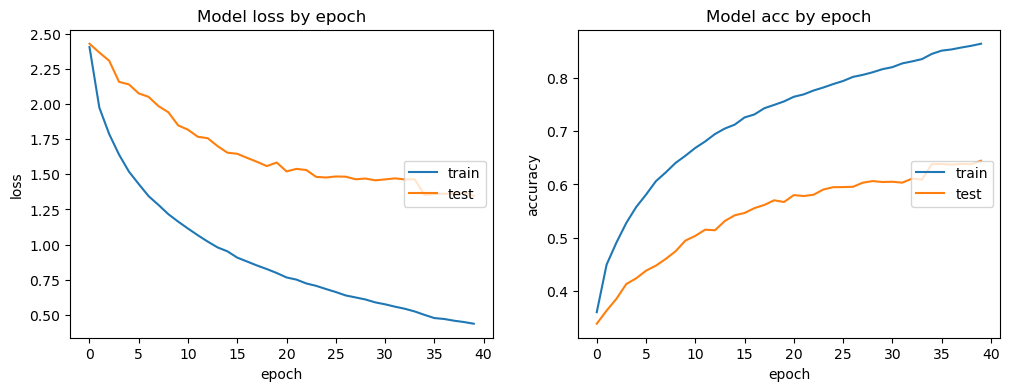

In [33]:



plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(tloss)
plt.plot(tvalloss)
plt.title('Model loss by epoch')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='right')

   

plt.subplot(122)
plt.plot(train_acc)
plt.plot(val_acc)
plt.title('Model acc by epoch')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='right');

### c) affichage des 3 meilleurs prédictions par catégorie
classé par ordre d'échantillonage obtenu après over et under sampling

In [34]:

#=========================================================================
dfp=pd.read_csv(dfpredict)
dfs=pd.read_csv(ds.get_RACINE_SAUVEGARDE()+STRATEGIE) # effectifs par classe retenu après over et under sampling
dfs.rename({'Unnamed: 0':'Categorie'},axis=1,inplace=True)
df_resume=dfs.merge(dfp,on='Categorie',how='inner')
df_resume.drop('Unnamed: 0',axis=1,inplace=True)
df_resume.head(27)

,Categorie,Qunatity,predict,pourc,predict2,pourc2,predict3,pourc3
0,1560,4000,1560,0.642000,2582,0.087000,2060,0.067000
1,1300,4000,1300,0.805000,1280,0.069000,50,0.019000
2,2583,4000,2583,0.863000,2522,0.026000,2585,0.019000
3,2060,3994,2060,0.509510,1560,0.116116,1920,0.059059
4,2522,3991,2522,0.749499,1560,0.025050,2060,0.024048
5,1280,3896,1280,0.410678,1300,0.174538,1281,0.065708
6,2403,3819,2403,0.661780,2280,0.140314,10,0.074346
7,2280,3808,2280,0.831933,2403,0.065126,10,0.037815
8,1920,3442,1920,0.850174,2060,0.039489,1560,0.031359
9,1160,3162,1160,0.919090,2403,0.017699,1281,0.013906


### d) matrice de confusion

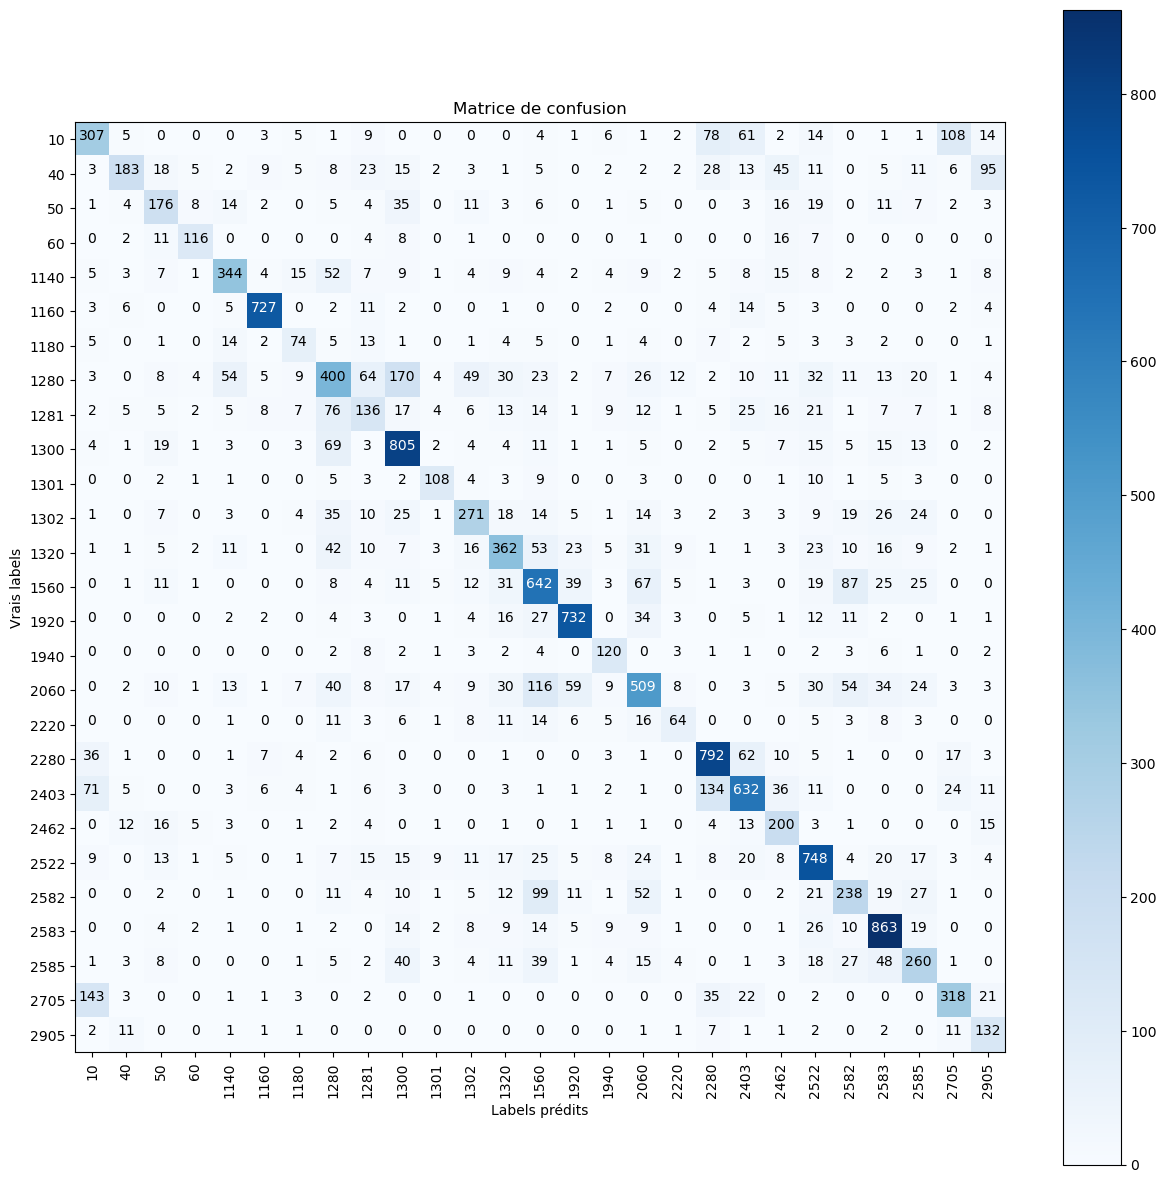

In [35]:
import itertools # Pour créer des itérateurs
#cnf_matrix = confusion_matrix(y_test, test_pred_orinal,labels=[10,2280,2403,2705,40,50,2462,1280,1281])
cnf_matrix = confusion_matrix(y_test, test_pred_original2,labels=sorted(list(set(y_test_original2))))
#print(cnf_matrix)


classes=sorted(list(set(y_test_original2)))
b=list(set(y_test_original2))

plt.figure(figsize=(15,15))

plt.imshow(cnf_matrix, interpolation='nearest',cmap='Blues')
plt.title("Matrice de confusion")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes,rotation=90)
plt.yticks(tick_marks, classes)

for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    plt.text(j, i, cnf_matrix[i, j],
             horizontalalignment = "center",
             color = "white" if cnf_matrix[i, j] > ( cnf_matrix.max() / 2) else "black")

plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


In [36]:
top5_df = pd.DataFrame({'prdtypecode': y_test_original2,'predict': test_pred_original2})
df_cross=pd.crosstab(top5_df['prdtypecode'], top5_df['predict'],normalize='index')
df_cross

predict,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
prdtypecode,,,,,,,,,,,,,,,,,,,,,
10,0.492777,0.008026,0.000000,0.000000,0.000000,0.004815,0.008026,0.001605,0.014446,0.000000,...,0.003210,0.125201,0.097913,0.003210,0.022472,0.000000,0.001605,0.001605,0.173355,0.022472
40,0.005976,0.364542,0.035857,0.009960,0.003984,0.017928,0.009960,0.015936,0.045817,0.029880,...,0.003984,0.055777,0.025896,0.089641,0.021912,0.000000,0.009960,0.021912,0.011952,0.189243
50,0.002976,0.011905,0.523810,0.023810,0.041667,0.005952,0.000000,0.014881,0.011905,0.104167,...,0.000000,0.000000,0.008929,0.047619,0.056548,0.000000,0.032738,0.020833,0.005952,0.008929
60,0.000000,0.012048,0.066265,0.698795,0.000000,0.000000,0.000000,0.000000,0.024096,0.048193,...,0.000000,0.000000,0.000000,0.096386,0.042169,0.000000,0.000000,0.000000,0.000000,0.000000
1140,0.009363,0.005618,0.013109,0.001873,0.644195,0.007491,0.028090,0.097378,0.013109,0.016854,...,0.003745,0.009363,0.014981,0.028090,0.014981,0.003745,0.003745,0.005618,0.001873,0.014981
1160,0.003793,0.007585,0.000000,0.000000,0.006321,0.919090,0.000000,0.002528,0.013906,0.002528,...,0.000000,0.005057,0.017699,0.006321,0.003793,0.000000,0.000000,0.000000,0.002528,0.005057
1180,0.032680,0.000000,0.006536,0.000000,0.091503,0.013072,0.483660,0.032680,0.084967,0.006536,...,0.000000,0.045752,0.013072,0.032680,0.019608,0.019608,0.013072,0.000000,0.000000,0.006536
1280,0.003080,0.000000,0.008214,0.004107,0.055441,0.005133,0.009240,0.410678,0.065708,0.174538,...,0.012320,0.002053,0.010267,0.011294,0.032854,0.011294,0.013347,0.020534,0.001027,0.004107
1281,0.004831,0.012077,0.012077,0.004831,0.012077,0.019324,0.016908,0.183575,0.328502,0.041063,...,0.002415,0.012077,0.060386,0.038647,0.050725,0.002415,0.016908,0.016908,0.002415,0.019324


### e) Rapport de classification

In [37]:
# On évalue le niveau de précision de notre prédiction.
print("Précision de la prédiction:", accuracy_score(y_test_original2, test_pred_original2)*100, '%')

print("Evaluation détaillée de la Classification par RDF :\n \n" ,
      (classification_report(y_test_original2, test_pred_original2)))

Précision de la prédiction: 64.44905138836538 %
Evaluation détaillée de la Classification par RDF :
 
               precision    recall  f1-score   support

          10       0.51      0.49      0.50       623
          40       0.74      0.36      0.49       502
          50       0.54      0.52      0.53       336
          60       0.77      0.70      0.73       166
        1140       0.70      0.64      0.67       534
        1160       0.93      0.92      0.93       791
        1180       0.51      0.48      0.50       153
        1280       0.50      0.41      0.45       974
        1281       0.38      0.33      0.35       414
        1300       0.66      0.81      0.73      1000
        1301       0.71      0.67      0.69       161
        1302       0.62      0.54      0.58       498
        1320       0.61      0.56      0.58       648
        1560       0.57      0.64      0.60      1000
        1920       0.82      0.85      0.83       861
        1940       0.59      0.7

### f) Résumé de la classification obtenue

In [38]:
df_pred = pd.DataFrame()
for c in Lcat:
    print(c, '   ------   ', catdict[c])
    s = df_cross.loc[c].sort_values(ascending=False)[:5]
    df_temp = pd.DataFrame([{'Categorie':c,'predict':s.index[0],'pourc':s.values[0],'predict2':s.index[1],'pourc2':s.values[1],'predict3':s.index[2],'pourc3':s.values[2]}])
    df_pred = pd.concat([df_pred, df_temp], ignore_index=True)
    for index, value in s.items():  # Change ici
        print(f"  : {index},  : {np.round(value*100,2)} % , {catdict[index]}")
df_pred.to_csv(dfpredict)

10    ------    livres
  : 10,  : 49.28 % , livres
  : 2705,  : 17.34 % , bds et livres
  : 2280,  : 12.52 % , magazines
  : 2403,  : 9.79 % , livres et bds
  : 2522,  : 2.25 % , produits de papeterie et rangement bureau
40    ------    jeux video pour pc et consoles
  : 40,  : 36.45 % , jeux video pour pc et consoles
  : 2905,  : 18.92 % , Jeu En téléchargement
  : 2462,  : 8.96 % , consoles de jeux video et jeux videos
  : 2280,  : 5.58 % , magazines
  : 1281,  : 4.58 % , jeux de societe/cartes
50    ------     accesoires jeux video
  : 50,  : 52.38 % ,  accesoires jeux video
  : 1300,  : 10.42 % , Petites voitures (jouets) et maquettes
  : 2522,  : 5.65 % , produits de papeterie et rangement bureau
  : 2462,  : 4.76 % , consoles de jeux video et jeux videos
  : 1140,  : 4.17 % , produits derives “geeks” et figurines
60    ------    consoles de jeux video
  : 60,  : 69.88 % , consoles de jeux video
  : 2462,  : 9.64 % , consoles de jeux video et jeux videos
  : 50,  : 6.63 % ,  acces

### III) Tracé sur 40 epoques
### a) Ajout au tableau général

In [30]:
CNN="CNN22"
PGM="Model_Img_Reseau_RGB_EfficientNetB1_V01"
LIBBELLE="EfficientNetB1 Adam 4000-2000 SIZE400 DeFreeze  DR40-CC1024-CC1024-DR40"

In [39]:
df_val_accuracy= pd.read_csv(ds.get_RACINE_SAUVEGARDE()+'df_val_accuracy.csv')
print(df_val_accuracy['id'].value_counts())
print(df_val_accuracy['libelle'].value_counts())
df_val_accuracy.head()



id
UNDER01    40
UNDER03    40
UNDER02    40
UNDER04    40
CNN01      40
CNN02      40
UNDER06    40
UNDER05    40
CNN03      40
CNN05      40
CNN04      40
CNN06      40
CNN07      40
CNN08      40
CNN21      40
CNN22      40
Name: count, dtype: int64
libelle
undersampling max 2400                                                     40
undersampling max 764                                                      40
undersampling max 2400 class_weight                                        40
undersampling max 2400 avec BatchNormalization                             40
CNN Max 2500 - MIN 1400                                                    40
CNN avec ImageDataGenerator                                                40
undersampling max 2400 L2=0.0001                                           40
undersampling max 2400 L1=0.0001                                           40
efficientNet RGB max 2500 lr=0.01->0.0042 DR20-20                          40
efficientNet RGB max 4000 lr=0.01->0.

,Unnamed: 0,Epoch,val_accuracy,programme,libelle,id
0,0,1,0.181025,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
1,1,2,0.214916,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
2,2,3,0.211974,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
3,3,4,0.223237,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
4,4,5,0.230238,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01


In [39]:
if len(val_acc) <40:
    raise SystemExit("Arrêt de l'exécution de la cellule car la longueur de val_acc est imcompatible avec la suite du traitement !")
df_val_accuracy= pd.read_csv(ds.get_RACINE_SAUVEGARDE() +'df_val_accuracy.csv')
df_val_accuracy.drop('Unnamed: 0',axis=1,inplace=True)
print(df_val_accuracy.head())
print('*******************')
print(df_val_accuracy.tail())
print('*******************')
df_val_accuracy2 = pd.DataFrame(list(val_acc)[:40],index=np.arange(1 , 41, 1),columns =['val_accuracy'])
print(df_val_accuracy2.head())
print('*******************')
df_val_accuracy2['programme']=PGM
df_val_accuracy2['libelle']=LIBBELLE
df_val_accuracy2['id']=CNN
df_val_accuracy2.reset_index(inplace=True)
df_val_accuracy2 = df_val_accuracy2.rename(columns={"index": "Epoch"})
df_val_accuracy=df_val_accuracy[df_val_accuracy['id'] != CNN]
df_val_accuracy = pd.concat([df_val_accuracy,df_val_accuracy2])
df_val_accuracy.to_csv(ds.get_RACINE_SAUVEGARDE() +'df_val_accuracy.csv')
print(df_val_accuracy.head())
print('*******************')
print(df_val_accuracy.tail())

   Epoch  val_accuracy                               programme  \
0      1      0.181025  Modele_IMG_Reseau_images_undersampling   
1      2      0.214916  Modele_IMG_Reseau_images_undersampling   
2      3      0.211974  Modele_IMG_Reseau_images_undersampling   
3      4      0.223237  Modele_IMG_Reseau_images_undersampling   
4      5      0.230238  Modele_IMG_Reseau_images_undersampling   

                  libelle       id  
0  undersampling max 2400  UNDER01  
1  undersampling max 2400  UNDER01  
2  undersampling max 2400  UNDER01  
3  undersampling max 2400  UNDER01  
4  undersampling max 2400  UNDER01  
*******************
     Epoch  val_accuracy                        programme  \
595     36      0.597379  Modele_Img_Reseau_RGB_VGG16_aug   
596     37      0.600530  Modele_Img_Reseau_RGB_VGG16_aug   
597     38      0.601747  Modele_Img_Reseau_RGB_VGG16_aug   
598     39      0.598668  Modele_Img_Reseau_RGB_VGG16_aug   
599     40      0.597236  Modele_Img_Reseau_RGB_VGG16_au

In [33]:
df_accuracy= pd.read_csv(ds.get_RACINE_SAUVEGARDE()+'df_accuracy.csv')
df_accuracy.head()

,Unnamed: 0,Epoch,accuracy,programme,libelle,id
0,0,1,0.139686,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
1,1,2,0.186874,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
2,2,3,0.205952,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
3,3,4,0.220996,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
4,4,5,0.234594,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01


In [40]:
if len(train_acc) < 40:
    raise SystemExit("Arrêt de l'exécution de la cellule car la longueur de train_acc est imcompatible avec la suite du traitement !")
df_val_accuracy= pd.read_csv(ds.get_RACINE_SAUVEGARDE() +'df_accuracy.csv')
df_val_accuracy.drop('Unnamed: 0',axis=1,inplace=True)
print(df_val_accuracy.head())
print('*******************')
df_val_accuracy2 = pd.DataFrame(list(train_acc)[:40],index=np.arange(1 , 41, 1),columns =['accuracy'])
print(df_val_accuracy2.head())
print('*******************')
df_val_accuracy2['programme']=PGM
df_val_accuracy2['libelle']=LIBBELLE
df_val_accuracy2['id']=CNN
df_val_accuracy2.reset_index(inplace=True)
df_val_accuracy2 = df_val_accuracy2.rename(columns={"index": "Epoch"})
df_val_accuracy=df_val_accuracy[df_val_accuracy['id'] != CNN]
df_val_accuracy = pd.concat([df_val_accuracy,df_val_accuracy2])
df_val_accuracy.to_csv(ds.get_RACINE_SAUVEGARDE() +'df_accuracy.csv')
print(df_val_accuracy.head())
print('*******************')
print(df_val_accuracy.tail())

   Epoch  accuracy                               programme  \
0      1  0.139686  Modele_IMG_Reseau_images_undersampling   
1      2  0.186874  Modele_IMG_Reseau_images_undersampling   
2      3  0.205952  Modele_IMG_Reseau_images_undersampling   
3      4  0.220996  Modele_IMG_Reseau_images_undersampling   
4      5  0.234594  Modele_IMG_Reseau_images_undersampling   

                  libelle       id  
0  undersampling max 2400  UNDER01  
1  undersampling max 2400  UNDER01  
2  undersampling max 2400  UNDER01  
3  undersampling max 2400  UNDER01  
4  undersampling max 2400  UNDER01  
*******************
   accuracy
1  0.377881
2  0.463278
3  0.504489
4  0.540783
5  0.566754
*******************
   Epoch  accuracy                               programme  \
0      1  0.139686  Modele_IMG_Reseau_images_undersampling   
1      2  0.186874  Modele_IMG_Reseau_images_undersampling   
2      3  0.205952  Modele_IMG_Reseau_images_undersampling   
3      4  0.220996  Modele_IMG_Reseau_images_

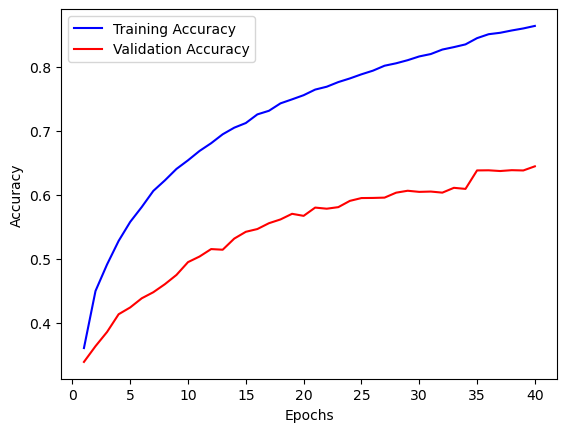

In [40]:
# Labels des axes
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Courbe de la précision sur l'échantillon d'entrainement
plt.plot(np.arange(1 , 41, 1),
         training_history.history['accuracy'],
         label = 'Training Accuracy',
         color = 'blue')

# Courbe de la précision sur l'échantillon de test
plt.plot(np.arange(1 ,41, 1),
         training_history.history['val_accuracy'],
         label = 'Validation Accuracy',
         color = 'red')

# Affichage de la légende
plt.legend()

# Affichage de la figure
plt.show()


In [37]:
df_report= pd.read_csv(ds.get_RACINE_SAUVEGARDE() +'df_report.csv')
df_report.head()

,Unnamed: 0,Categorie,precision,recall,f1-score,support,programme,libelle,id
0,0,10,0.454386,0.431667,0.442735,600.0,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
1,1,40,0.409786,0.266932,0.323281,502.0,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
2,2,50,0.233161,0.133929,0.170132,336.0,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
3,3,60,0.123457,0.180723,0.146699,166.0,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01
4,4,1140,0.174033,0.353933,0.233333,534.0,Modele_IMG_Reseau_images_undersampling,undersampling max 2400,UNDER01


In [42]:

report_dict = classification_report(y_test, test_pred_original2, output_dict=True)

# Conversion du rapport de classification en DataFrame
df_report2 = pd.DataFrame(report_dict).transpose()
df_report2['programme']=PGM
df_report2['libelle']=LIBBELLE
df_report2['id']=CNN
df_report2.reset_index(inplace=True)
df_report2 = df_report2.rename(columns={"index": "Categorie"})
df_report=df_report[df_report['id'] != CNN]
df_report = pd.concat([df_report,df_report2])
#df_report.drop('Unnamed: 0',axis=1,inplace=True)
df_report.to_csv(ds.get_RACINE_SAUVEGARDE() +'df_report.csv')
df_report.tail(50)

,Categorie,precision,recall,f1-score,support,programme,libelle,id
578,1301,0.690217,0.788820,0.736232,161.000000,Model_Img_Reseau_RGB_EfficientNetB5_V01,EfficientNetB5 4000-2000 SIZE400 DEFREEZE DR4...,CNN26
579,1302,0.634146,0.574297,0.602740,498.000000,Model_Img_Reseau_RGB_EfficientNetB5_V01,EfficientNetB5 4000-2000 SIZE400 DEFREEZE DR4...,CNN26
580,1320,0.628920,0.557099,0.590835,648.000000,Model_Img_Reseau_RGB_EfficientNetB5_V01,EfficientNetB5 4000-2000 SIZE400 DEFREEZE DR4...,CNN26
581,1560,0.661053,0.628000,0.644103,1000.000000,Model_Img_Reseau_RGB_EfficientNetB5_V01,EfficientNetB5 4000-2000 SIZE400 DEFREEZE DR4...,CNN26
582,1920,0.816964,0.850174,0.833238,861.000000,Model_Img_Reseau_RGB_EfficientNetB5_V01,EfficientNetB5 4000-2000 SIZE400 DEFREEZE DR4...,CNN26
583,1940,0.629630,0.844720,0.721485,161.000000,Model_Img_Reseau_RGB_EfficientNetB5_V01,EfficientNetB5 4000-2000 SIZE400 DEFREEZE DR4...,CNN26
584,2060,0.594039,0.578579,0.586207,999.000000,Model_Img_Reseau_RGB_EfficientNetB5_V01,EfficientNetB5 4000-2000 SIZE400 DEFREEZE DR4...,CNN26
585,2220,0.493590,0.466667,0.479751,165.000000,Model_Img_Reseau_RGB_EfficientNetB5_V01,EfficientNetB5 4000-2000 SIZE400 DEFREEZE DR4...,CNN26
586,2280,0.784679,0.796218,0.790407,952.000000,Model_Img_Reseau_RGB_EfficientNetB5_V01,EfficientNetB5 4000-2000 SIZE400 DEFREEZE DR4...,CNN26
587,2403,0.722163,0.713089,0.717597,955.000000,Model_Img_Reseau_RGB_EfficientNetB5_V01,EfficientNetB5 4000-2000 SIZE400 DEFREEZE DR4...,CNN26


###  RECUPERER  LES DONNEES SAUVAGARDEES

In [10]:
saveweights = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_weights.h5'
trainacc  = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_train_acc.pkl'
valacc = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_val_acc.pkl'
loss = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_loss.pkl'
valloss = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_valloss.pkl'
dfpredict = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+ '_df_predict.csv'
testoriginal = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_y_test_original2.pkl'
predoriginal = ds.get_RACINE_SAUVEGARDE()+SUFFIXE_FICHIER+'_test_pred_original2.pkl'

In [12]:
import pickle
with open(trainacc, 'rb') as f:
    train_acc = pickle.load(f)
with open(valacc, 'rb') as f:
    val_acc = pickle.load(f)
with open(loss, 'rb') as f:
    tloss = pickle.load(f)
with open(valloss, 'rb') as f:
    tvalloss = pickle.load(f)    

### b) affichage des precisions et des pertes par époque

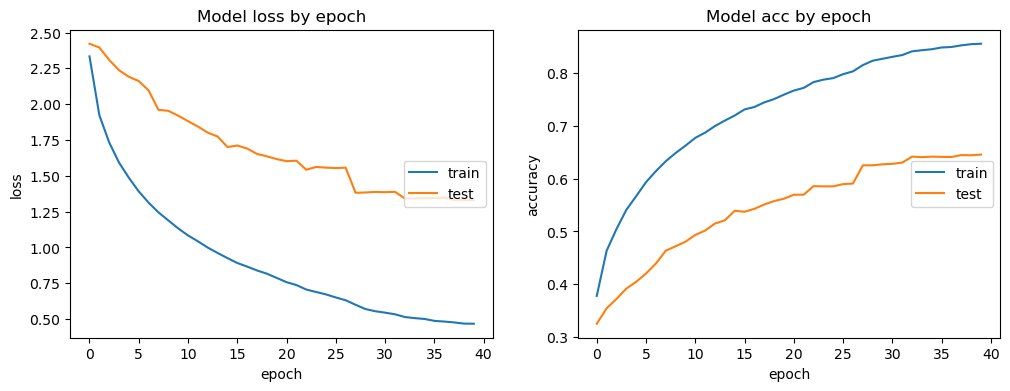

In [13]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(tloss)
plt.plot(tvalloss)
plt.title('Model loss by epoch')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='right')

plt.subplot(122)
plt.plot(train_acc)
plt.plot(val_acc)
plt.title('Model acc by epoch')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='right');

### c) affichage des 3 meilleurs prédictions par catégorie
classé par ordre d'échantillonage obtenu après over et under sampling

In [23]:
#=========================================================================
dfp=pd.read_csv(dfpredict)
dfs=pd.read_csv(ds.get_RACINE_SAUVEGARDE()+STRATEGIE) # effectifs par classe retenu après over et under sampling
dfs.rename({'Unnamed: 0':'Categorie'},axis=1,inplace=True)
df_resume=dfs.merge(dfp,on='Categorie',how='inner')
df_resume.drop('Unnamed: 0',axis=1,inplace=True)
df_resume.head(27)

,Categorie,Qunatity,predict,pourc,predict2,pourc2,predict3,pourc3
0,1560,4000,1560,0.653000,2582,0.086000,2060,0.080000
1,1300,4000,1300,0.827000,1280,0.041000,2585,0.023000
2,2583,4000,2583,0.836000,2585,0.027000,2582,0.021000
3,2060,3994,2060,0.527528,1560,0.093093,1920,0.065065
4,2522,3991,2522,0.745491,1560,0.031062,2585,0.022044
5,1280,3896,1280,0.393224,1300,0.187885,1140,0.068789
6,2403,3819,2403,0.638743,2280,0.156021,10,0.068063
7,2280,3808,2280,0.813025,2403,0.072479,10,0.063025
8,1920,3442,1920,0.829268,1560,0.051103,2060,0.034843
9,1160,3162,1160,0.916561,1281,0.020228,2462,0.013906


### d) matrice de confusion

In [25]:
with open(testoriginal, 'rb') as f:
    y_test_original2 = pickle.load(f)
with open(predoriginal, 'rb') as f:
    test_pred_original2 = pickle.load(f)
with open(ds.get_RACINE_SAUVEGARDE() + 'y_train.pkl', 'rb') as f:
   y_train = pickle.load(f)
with open(ds.get_RACINE_SAUVEGARDE() + 'y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)


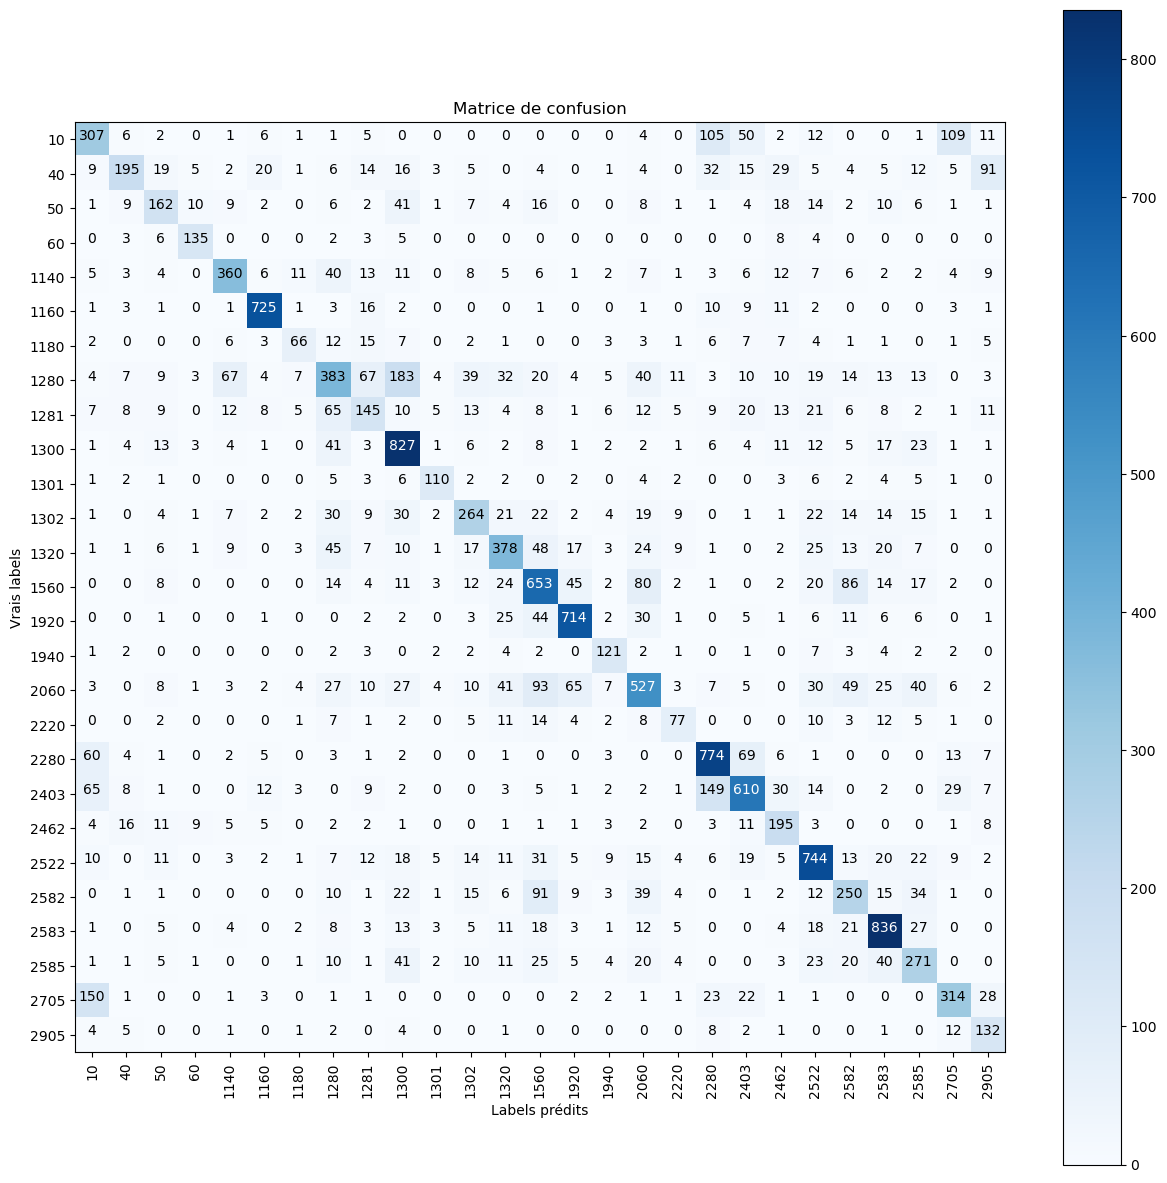

In [26]:
import itertools # Pour créer des itérateurs
#cnf_matrix = confusion_matrix(y_test, test_pred_orinal,labels=[10,2280,2403,2705,40,50,2462,1280,1281])
cnf_matrix = confusion_matrix(y_test, test_pred_original2,labels=sorted(list(set(y_test_original2))))
#print(cnf_matrix)


classes=sorted(list(set(y_test_original2)))
b=list(set(y_test_original2))

plt.figure(figsize=(15,15))

plt.imshow(cnf_matrix, interpolation='nearest',cmap='Blues')
plt.title("Matrice de confusion")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes,rotation=90)
plt.yticks(tick_marks, classes)

for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    plt.text(j, i, cnf_matrix[i, j],
             horizontalalignment = "center",
             color = "white" if cnf_matrix[i, j] > ( cnf_matrix.max() / 2) else "black")

plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


In [27]:
top5_df = pd.DataFrame({'prdtypecode': y_test_original2,'predict': test_pred_original2})
df_cross=pd.crosstab(top5_df['prdtypecode'], top5_df['predict'],normalize='index')
df_cross


predict,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
prdtypecode,,,,,,,,,,,,,,,,,,,,,
10,0.492777,0.009631,0.003210,0.000000,0.001605,0.009631,0.001605,0.001605,0.008026,0.000000,...,0.000000,0.168539,0.080257,0.003210,0.019262,0.000000,0.000000,0.001605,0.174960,0.017657
40,0.017928,0.388446,0.037849,0.009960,0.003984,0.039841,0.001992,0.011952,0.027888,0.031873,...,0.000000,0.063745,0.029880,0.057769,0.009960,0.007968,0.009960,0.023904,0.009960,0.181275
50,0.002976,0.026786,0.482143,0.029762,0.026786,0.005952,0.000000,0.017857,0.005952,0.122024,...,0.002976,0.002976,0.011905,0.053571,0.041667,0.005952,0.029762,0.017857,0.002976,0.002976
60,0.000000,0.018072,0.036145,0.813253,0.000000,0.000000,0.000000,0.012048,0.018072,0.030120,...,0.000000,0.000000,0.000000,0.048193,0.024096,0.000000,0.000000,0.000000,0.000000,0.000000
1140,0.009363,0.005618,0.007491,0.000000,0.674157,0.011236,0.020599,0.074906,0.024345,0.020599,...,0.001873,0.005618,0.011236,0.022472,0.013109,0.011236,0.003745,0.003745,0.007491,0.016854
1160,0.001264,0.003793,0.001264,0.000000,0.001264,0.916561,0.001264,0.003793,0.020228,0.002528,...,0.000000,0.012642,0.011378,0.013906,0.002528,0.000000,0.000000,0.000000,0.003793,0.001264
1180,0.013072,0.000000,0.000000,0.000000,0.039216,0.019608,0.431373,0.078431,0.098039,0.045752,...,0.006536,0.039216,0.045752,0.045752,0.026144,0.006536,0.006536,0.000000,0.006536,0.032680
1280,0.004107,0.007187,0.009240,0.003080,0.068789,0.004107,0.007187,0.393224,0.068789,0.187885,...,0.011294,0.003080,0.010267,0.010267,0.019507,0.014374,0.013347,0.013347,0.000000,0.003080
1281,0.016908,0.019324,0.021739,0.000000,0.028986,0.019324,0.012077,0.157005,0.350242,0.024155,...,0.012077,0.021739,0.048309,0.031401,0.050725,0.014493,0.019324,0.004831,0.002415,0.026570


### e) Rapport de classification

In [28]:
# On évalue le niveau de précision de notre prédiction.
print("Précision de la prédiction:", accuracy_score(y_test_original2, test_pred_original2)*100, '%')

print("Evaluation détaillée de la Classification par RDF :\n \n" ,
      (classification_report(y_test_original2, test_pred_original2)))

Précision de la prédiction: 64.54956652845834 %
Evaluation détaillée de la Classification par RDF :
 
               precision    recall  f1-score   support

          10       0.48      0.49      0.49       623
          40       0.70      0.39      0.50       502
          50       0.56      0.48      0.52       336
          60       0.80      0.81      0.81       166
        1140       0.72      0.67      0.70       534
        1160       0.90      0.92      0.91       791
        1180       0.60      0.43      0.50       153
        1280       0.52      0.39      0.45       974
        1281       0.41      0.35      0.38       414
        1300       0.64      0.83      0.72      1000
        1301       0.75      0.68      0.71       161
        1302       0.60      0.53      0.56       498
        1320       0.63      0.58      0.61       648
        1560       0.59      0.65      0.62      1000
        1920       0.81      0.83      0.82       861
        1940       0.65      0.7

### f) Résumé de la classification obtenue

In [29]:
df_pred = pd.DataFrame()
for c in Lcat:
    print(c, '   ------   ', catdict[c])
    s = df_cross.loc[c].sort_values(ascending=False)[:5]
    df_temp = pd.DataFrame([{'Categorie':c,'predict':s.index[0],'pourc':s.values[0],'predict2':s.index[1],'pourc2':s.values[1],'predict3':s.index[2],'pourc3':s.values[2]}])
    df_pred = pd.concat([df_pred, df_temp], ignore_index=True)
    for index, value in s.items():  # Change ici
        print(f"  : {index},  : {np.round(value*100,2)} % , {catdict[index]}")

10    ------    livres
  : 10,  : 49.28 % , livres
  : 2705,  : 17.5 % , bds et livres
  : 2280,  : 16.85 % , magazines
  : 2403,  : 8.03 % , livres et bds
  : 2522,  : 1.93 % , produits de papeterie et rangement bureau
40    ------    jeux video pour pc et consoles
  : 40,  : 38.84 % , jeux video pour pc et consoles
  : 2905,  : 18.13 % , Jeu En téléchargement
  : 2280,  : 6.37 % , magazines
  : 2462,  : 5.78 % , consoles de jeux video et jeux videos
  : 1160,  : 3.98 % , cartes collectionables
50    ------     accesoires jeux video
  : 50,  : 48.21 % ,  accesoires jeux video
  : 1300,  : 12.2 % , Petites voitures (jouets) et maquettes
  : 2462,  : 5.36 % , consoles de jeux video et jeux videos
  : 1560,  : 4.76 % , Mobilier et produits decoration/rangement pour la maison
  : 2522,  : 4.17 % , produits de papeterie et rangement bureau
60    ------    consoles de jeux video
  : 60,  : 81.33 % , consoles de jeux video
  : 2462,  : 4.82 % , consoles de jeux video et jeux videos
  : 50,  

# I) Recherche du meilleur modèle 
## test sur : optimizer, lrate, nb neuronnes, dropout
### a) premier type

            model = Sequential()
            model.add(base_model) # Ajout du modèle  EfficientNetB1
            model.add(Flatten())
            model.add(Dropout(dprout))
            model.add(Dense(niv1, activation='relu'))
            model.add(BatchNormalization())
            model.add(Dense(niv1//2, activation='relu'))
            model.add(Dropout(dprout))
            model.add(Dense(27, activation='softmax'))

In [27]:
chemin_du_fichier = ds.get_RACINE_SAUVEGARDE() +'param_grid_'+SUFFIXE_FICHIER+'.csv'
noms_de_colonnes = ['Modele','Lrate', 'NbNeurones_Layer1', 'NbNeurones_Layer2','Dropout','Accuracy','Loss','Val_accuracy','Val_loss']

df_reseaux = pd.DataFrame(columns=noms_de_colonnes)    
# Vérifiez si le fichier existe
if os.path.isfile(chemin_du_fichier):
    # Le fichier existe, le lire
    df_reseaux = pd.read_csv(chemin_du_fichier)
    print("Fichier existant lu avec succès.")
    print(df_reseaux['Lrate'].value_counts())
    print(df_reseaux['NbNeurones_Layer1'].value_counts())
    print(df_reseaux['Dropout'].value_counts())
else:
    # Le fichier n'existe pas, créer un nouveau DataFrame et le sauvegarder
    df_reseaux = pd.DataFrame(columns=noms_de_colonnes)    

Fichier existant lu avec succès.
Lrate
0.00001    18
Name: count, dtype: int64
NbNeurones_Layer1
1024    6
512     6
128     6
Name: count, dtype: int64
Dropout
0.2    6
0.3    6
0.4    6
Name: count, dtype: int64


In [26]:
df_reseaux.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         18 non-null     int64  
 1   Modele             18 non-null     object 
 2   Lrate              18 non-null     float64
 3   NbNeurones_Layer1  18 non-null     int64  
 4   NbNeurones_Layer2  18 non-null     int64  
 5   Dropout            18 non-null     float64
 6   Accuracy           18 non-null     object 
 7   Loss               18 non-null     object 
 8   Val_accuracy       18 non-null     object 
 9   Val_loss           18 non-null     object 
dtypes: float64(2), int64(3), object(5)
memory usage: 1.5+ KB


In [26]:
df_reseaux = df_reseaux.drop('Unnamed: 0', axis=1)

df_reseaux[['Modele','Lrate', 'NbNeurones_Layer1', 'Dropout']].head()

,Modele,Lrate,NbNeurones_Layer1,Dropout
0,Adam,0.00001,1024,0.2
1,SGD,0.00001,1024,0.2
2,Adam,0.00001,1024,0.3
3,SGD,0.00001,1024,0.3
4,Adam,0.00001,1024,0.4


In [ ]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.models import Model, Sequential, load_model


#for lrate in  [1e-5,5e-6,1e-6]:
for lrate in  [1e-5]:    
    for niv1 in [1024,512,128]:   
        for dprout in [0.20,0.30,0.40]:
            print("=====================  Adam   ============================")
            print("=====================  categorical_crossentropy   ============================")
            print('lrate = ' ,lrate)
            print('niv1 = ' ,niv1,niv1//2)
            print('dprout = ' ,dprout)
            condition = (
                (df_reseaux['Modele'] == 'Adam') &
                (df_reseaux['Lrate'] == lrate) &
                (df_reseaux['NbNeurones_Layer1'] == niv1) &
                (df_reseaux['Dropout'] == dprout)
            )
            on_execute = True
            if df_reseaux[condition].any().any():
                print("On passe")
                on_execute = False
            model = Sequential()
            model.add(base_model) # Ajout du modèle  EfficientNetB1
            model.add(Flatten())
            model.add(Dropout(dprout))
            model.add(Dense(niv1, activation='relu'))
            model.add(BatchNormalization())
            model.add(Dense(niv1//2, activation='relu'))
            model.add(Dropout(dprout))
            model.add(Dense(27, activation='softmax'))
            if on_execute :
                model.compile(optimizer=Adam(learning_rate=lrate), loss='categorical_crossentropy', metrics=['accuracy'])
                #print(model.summary())
                training_history = model.fit(dataset_train, epochs=3, validation_data = dataset_test)
                train_acc = training_history.history['accuracy']
                val_acc = training_history.history['val_accuracy']
                tloss = training_history.history['loss']
                tvalloss=training_history.history['val_loss']
                df_reseaux.loc[len(df_reseaux)] = ['Adam',lrate, niv1,niv1//2, dprout,train_acc,tloss,val_acc,tvalloss]
                print(type(df_reseaux))
                print('Adam',lrate, niv1, dprout,train_acc,tloss,val_acc,tvalloss)
                #df_reseaux = df_reseaux.append({'Modele': 'Adam', 'Lrate': lrate, 'NbNeurones_Layer1': niv1,
                #        'NbNeurones_Layer2': niv1//2, 'Dropout': dprout, 'TrainAcc': train_acc, 'Tloss': tloss,
                #        'ValAcc': val_acc, 'Tvalloss': tvalloss})
                df_reseaux.to_csv( chemin_du_fichier)       
                #del training_history
                #gc.collect()
            print("=====================  SGD   ============================")
            print("=====================  categorical_crossentropy   ============================")
            print('lrate = ' ,lrate)
            print('niv1 = ' ,niv1,niv1//2)
            print('dprout = ' ,dprout)
            on_execute = True
            condition = (
                (df_reseaux['Modele'] == 'SGD') &
                (df_reseaux['Lrate'] == lrate) &
                (df_reseaux['NbNeurones_Layer1'] == niv1) &
                (df_reseaux['Dropout'] == dprout)
            )
            if df_reseaux[condition].any().any():
                print("On passe")
                on_execute = False
            model = Sequential()
            model.add(base_model) # Ajout du modèle  EfficientNetB1
            model.add(Flatten())
            model.add(Dropout(dprout))
            model.add(Dense(niv1, activation='relu'))
            model.add(BatchNormalization())
            model.add(Dense(niv1//2, activation='relu'))
            model.add(Dropout(dprout))
            model.add(Dense(27, activation='softmax'))
            if on_execute :
                model.compile(optimizer=SGD(learning_rate=lrate), loss='categorical_crossentropy', metrics=['accuracy'])
                training_history = model.fit(dataset_train, epochs=3, validation_data = dataset_test)
                train_acc = training_history.history['accuracy']
                val_acc = training_history.history['val_accuracy']
                tloss = training_history.history['loss']
                tvalloss=training_history.history['val_loss']
                df_reseaux.loc[len(df_reseaux)] = ['SGD',lrate, niv1,niv1//2, dprout,train_acc,tloss,val_acc,tvalloss]
                #df_reseaux = df_reseaux.append({'Modele': 'SGD', 'Lrate': lrate, 'NbNeurones_Layer1': niv1,
                #        'NbNeurones_Layer2': niv1//2, 'Dropout': dprout, 'TrainAcc': train_acc, 'Tloss': tloss,
                #        'ValAcc': val_acc, 'Tvalloss': tvalloss}, ignore_index=True)
                df_reseaux.to_csv( chemin_du_fichier)       
                #del training_history
                #gc.collect()
                print("=========================================================")
                print(df_reseaux)
df_reseaux.to_csv( chemin_du_fichier)            

=====================  Adam   ============================
=====================  categorical_crossentropy   ============================
lrate =  1e-05
niv1 =  1024 512
dprout =  0.2
On passe
=====================  SGD   ============================
=====================  categorical_crossentropy   ============================
lrate =  1e-05
niv1 =  1024 512
dprout =  0.2
On passe
=====================  Adam   ============================
=====================  categorical_crossentropy   ============================
lrate =  1e-05
niv1 =  1024 512
dprout =  0.3
On passe
=====================  SGD   ============================
=====================  categorical_crossentropy   ============================
lrate =  1e-05
niv1 =  1024 512
dprout =  0.3
On passe
=====================  Adam   ============================
=====================  categorical_crossentropy   ============================
lrate =  1e-05
niv1 =  1024 512
dprout =  0.4
On passe
=====================  SGD   ========

In [28]:
df_reseaux['Val_acc']=df_reseaux['Val_accuracy'].apply(lambda x : eval(x)[3])
df_reseaux[['Modele','Lrate','NbNeurones_Layer1','Dropout','Val_acc']].nlargest(5,'Val_acc')

,Modele,Lrate,NbNeurones_Layer1,Dropout,Val_acc
16,Adam,0.00001,128,0.4,0.537253
10,Adam,0.00001,512,0.4,0.494849
12,Adam,0.00001,128,0.2,0.494158
14,Adam,0.00001,128,0.3,0.480965
8,Adam,0.00001,512,0.3,0.445408


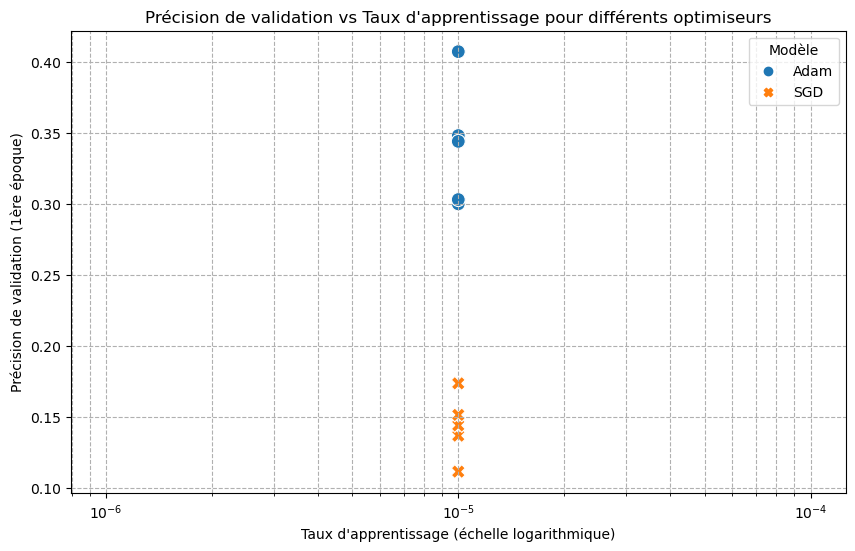

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Charger le fichier CSV
file_path = chemin_du_fichier  # Remplacez par le chemin réel du fichier
data = pd.read_csv(file_path)

# Convertir les chaînes de liste en listes réelles pour 'Val_accuracy'
data['Val_accuracy'] = data['Val_accuracy'].apply(ast.literal_eval)

# Extraire la première valeur de précision de validation pour chaque configuration
data['Val_accuracy_first_epoch'] = data['Val_accuracy'].apply(lambda x: x[0])

# Visualisation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Lrate', y='Val_accuracy_first_epoch', hue='Modele', style='Modele', s=100)
plt.xscale('log')
plt.xlabel('Taux d\'apprentissage (échelle logarithmique)')
plt.ylabel('Précision de validation (1ère époque)')
plt.title('Précision de validation vs Taux d\'apprentissage pour différents optimiseurs')
plt.legend(title='Modèle')
plt.grid(True, which="both", ls="--")
plt.show()


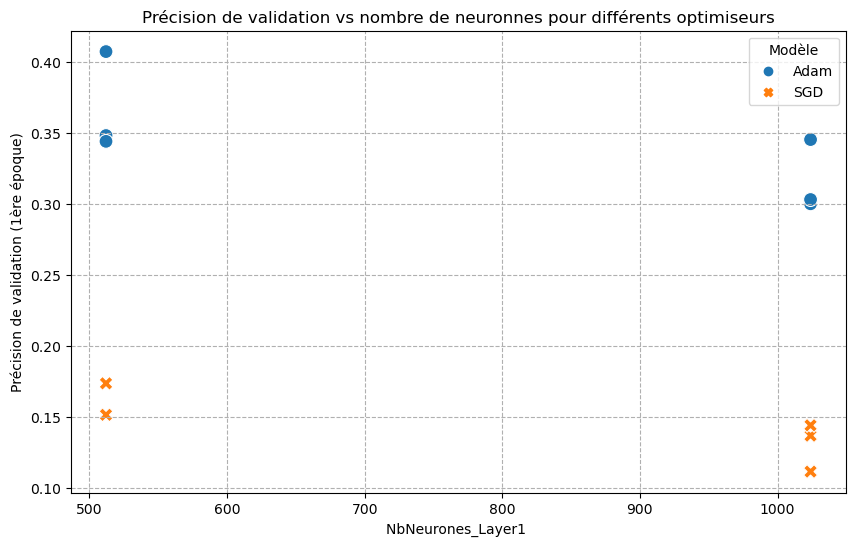

In [28]:
data = pd.read_csv(file_path)

# Convertir les chaînes de liste en listes réelles pour 'Val_accuracy'
data['Val_accuracy'] = data['Val_accuracy'].apply(ast.literal_eval)

# Extraire la première valeur de précision de validation pour chaque configuration
data['Val_accuracy_first_epoch'] = data['Val_accuracy'].apply(lambda x: x[0])

# Visualisation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='NbNeurones_Layer1', y='Val_accuracy_first_epoch', hue='Modele', style='Modele', s=100)
plt.xscale('linear')
plt.xlabel('NbNeurones_Layer1 ')
plt.ylabel('Précision de validation (1ère époque)')
plt.title('Précision de validation vs nombre de neuronnes pour différents optimiseurs')
plt.legend(title='Modèle')
plt.grid(True, which="both", ls="--")
plt.show()

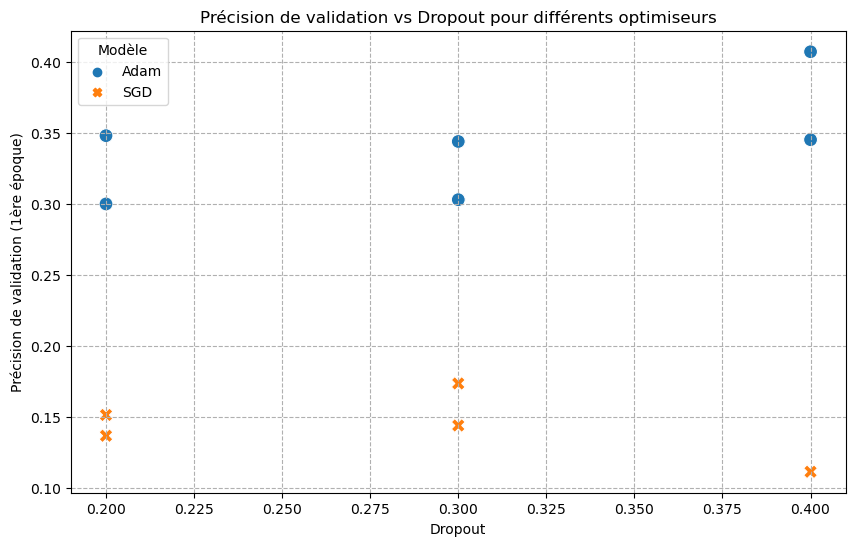

In [29]:
data = pd.read_csv(file_path)

# Convertir les chaînes de liste en listes réelles pour 'Val_accuracy'
data['Val_accuracy'] = data['Val_accuracy'].apply(ast.literal_eval)

# Extraire la première valeur de précision de validation pour chaque configuration
data['Val_accuracy_first_epoch'] = data['Val_accuracy'].apply(lambda x: x[0])

# Visualisation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Dropout', y='Val_accuracy_first_epoch', hue='Modele', style='Modele', s=100)
plt.xscale('linear')
plt.xlabel('Dropout')
plt.ylabel('Précision de validation (1ère époque)')
plt.title('Précision de validation vs Dropout pour différents optimiseurs')
plt.legend(title='Modèle')
plt.grid(True, which="both", ls="--")
plt.show()

### a) deuxième type

            model = Sequential()
            model.add(base_model) # Ajout du modèle  EfficientNetB1
            model.add(Flatten())
            model.add(Dropout(dprout))
            model.add(Dense(niv1, activation='relu'))
            model.add(BatchNormalization())
            model.add(Dense(niv1, activation='relu'))
            model.add(Dropout(dprout))
            model.add(Dense(27, activation='softmax'))

In [29]:
chemin_du_fichier_2 = ds.get_RACINE_SAUVEGARDE() +'param_grid2_'+SUFFIXE_FICHIER+'.csv'
noms_de_colonnes = ['Modele','Lrate', 'NbNeurones_Layer1', 'NbNeurones_Layer2','Dropout','Accuracy','Loss','Val_accuracy','Val_loss']

df_reseaux_2 = pd.DataFrame(columns=noms_de_colonnes)  
  
# Vérifiez si le fichier existe
if os.path.isfile(chemin_du_fichier_2):
    # Le fichier existe, le lire
    df_reseaux_2 = pd.read_csv(chemin_du_fichier_2)
    print("Fichier existant lu avec succès.")
    print(df_reseaux_2['Lrate'].value_counts())
    print(df_reseaux_2['NbNeurones_Layer1'].value_counts())
    print(df_reseaux_2['Dropout'].value_counts())
else:
    # Le fichier n'existe pas, créer un nouveau DataFrame et le sauvegarder
    df_reseaux_2 = pd.DataFrame(columns=noms_de_colonnes)   

Fichier existant lu avec succès.
Lrate
0.00001    18
Name: count, dtype: int64
NbNeurones_Layer1
1024    6
512     6
256     6
Name: count, dtype: int64
Dropout
0.2    6
0.3    6
0.4    6
Name: count, dtype: int64


In [24]:
df_reseaux_2.head()

,Unnamed: 0,Modele,Lrate,NbNeurones_Layer1,NbNeurones_Layer2,Dropout,Accuracy,Loss,Val_accuracy,Val_loss
0,0,Adam,0.00001,1024,1024,0.2,"[0.4143654406070709, 0.5051276087760925, 0.551...","[2.1405375003814697, 1.7471896409988403, 1.548...","[0.2779243588447571, 0.31090590357780457, 0.34...","[2.7276244163513184, 2.5889012813568115, 2.415..."
1,1,SGD,0.00001,1024,1024,0.2,"[0.06799690425395966, 0.12639056146144867, 0.1...","[3.632648468017578, 3.3191423416137695, 3.1182...","[0.15875110030174255, 0.25103655457496643, 0.3...","[3.1085240840911865, 2.802311897277832, 2.5989..."
2,2,Adam,0.00001,1024,1024,0.3,"[0.40415099263191223, 0.4934869110584259, 0.53...","[2.205925941467285, 1.798893690109253, 1.60479...","[0.307701975107193, 0.35004398226737976, 0.374...","[2.5918357372283936, 2.442429304122925, 2.3218..."
3,3,SGD,0.00001,1024,1024,0.3,"[0.056750111281871796, 0.1078224927186966, 0.1...","[3.7082154750823975, 3.4052348136901855, 3.199...","[0.15353688597679138, 0.24789546430110931, 0.3...","[3.069866895675659, 2.76082706451416, 2.558560..."
4,4,Adam,0.00001,1024,1024,0.4,"[0.38612622022628784, 0.46891510486602783, 0.5...","[2.3098976612091064, 1.9064180850982666, 1.695...","[0.3215228021144867, 0.36656615138053894, 0.38...","[2.579277515411377, 2.378835678100586, 2.33233..."


In [25]:
df_reseaux_2 = df_reseaux_2.drop('Unnamed: 0', axis=1)

df_reseaux_2[['Modele','Lrate', 'NbNeurones_Layer1', 'Dropout']].head()

,Modele,Lrate,NbNeurones_Layer1,Dropout
0,Adam,0.00001,1024,0.2
1,SGD,0.00001,1024,0.2
2,Adam,0.00001,1024,0.3
3,SGD,0.00001,1024,0.3
4,Adam,0.00001,1024,0.4


In [26]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.models import Model, Sequential, load_model
#for lrate in [1e-5,5e-6,1e-6]:
for lrate in [1e-5]:    
    for niv1 in [1024,512,256]:   
        for dprout in [0.20,0.30,0.40]:   
            print("=====================  Adam   ============================")
            print("=====================  categorical_crossentropy   ============================")
            print('lrate = ' ,lrate)
            print('niv1 = ' ,niv1)
            print('dprout = ' ,dprout)
            condition = (
                (df_reseaux_2['Modele'] == 'Adam') &
                (df_reseaux_2['Lrate'] == lrate) &
                (df_reseaux_2['NbNeurones_Layer1'] == niv1) &
                (df_reseaux_2['Dropout'] == dprout)
            )
            on_execute = True
            if df_reseaux_2[condition].any().any():
                print("On passe")
                on_execute = False
            model = Sequential()
            model.add(base_model) # Ajout du modèle  EfficientNetB1
            model.add(Flatten())
            model.add(Dropout(dprout))
            model.add(Dense(niv1, activation='relu'))
            model.add(BatchNormalization())
            model.add(Dense(niv1, activation='relu'))
            model.add(Dropout(dprout))
            model.add(Dense(27, activation='softmax'))
            if on_execute :    
                model.compile(optimizer=Adam(learning_rate=lrate), loss='categorical_crossentropy', metrics=['accuracy'])
                training_history = model.fit(dataset_train, epochs=4, validation_data = dataset_test)
                train_acc = training_history.history['accuracy']
                val_acc = training_history.history['val_accuracy']
                tloss = training_history.history['loss']
                tvalloss=training_history.history['val_loss']
                df_reseaux_2.loc[len(df_reseaux_2)] = ['Adam',lrate, niv1,niv1, dprout,train_acc,tloss,val_acc,tvalloss]
                df_reseaux_2.to_csv( chemin_du_fichier_2) 
            print("=====================  SGD   ============================")
            print("=====================  categorical_crossentropy   ============================")
            print('lrate = ' ,lrate)
            print('niv1 = ' ,niv1)
            print('dprout = ' ,dprout)
            on_execute = True
            condition = (
                (df_reseaux_2['Modele'] == 'SGD') &
                (df_reseaux_2['Lrate'] == lrate) &
                (df_reseaux_2['NbNeurones_Layer1'] == niv1) &
                (df_reseaux_2['Dropout'] == dprout)
            )
            if df_reseaux_2[condition].any().any():
                print("On passe")
                on_execute = False
            model = Sequential()
            model.add(base_model) # Ajout du modèle  EfficientNetB1
            model.add(Flatten())
            model.add(Dropout(dprout))
            model.add(Dense(niv1, activation='relu'))
            model.add(BatchNormalization())
            model.add(Dense(niv1, activation='relu'))
            model.add(Dropout(dprout))
            model.add(Dense(27, activation='softmax'))
            if on_execute :  
                model.compile(optimizer=SGD(learning_rate=lrate), loss='categorical_crossentropy', metrics=['accuracy'])
                training_history = model.fit(dataset_train, epochs=4, validation_data = dataset_test)
                train_acc = training_history.history['accuracy']
                val_acc = training_history.history['val_accuracy']
                tloss = training_history.history['loss']
                tvalloss=training_history.history['val_loss']
                df_reseaux_2.loc[len(df_reseaux_2)] = ['SGD',lrate, niv1,niv1, dprout,train_acc,tloss,val_acc,tvalloss]
                df_reseaux_2.to_csv( chemin_du_fichier_2) 
                print("=========================================================")
                print(df_reseaux_2)
df_reseaux_2.to_csv( chemin_du_fichier_2)                 

=====================  Adam   ============================
=====================  categorical_crossentropy   ============================
lrate =  1e-05
niv1 =  1024
dprout =  0.2
On passe
=====================  SGD   ============================
=====================  categorical_crossentropy   ============================
lrate =  1e-05
niv1 =  1024
dprout =  0.2
On passe
=====================  Adam   ============================
=====================  categorical_crossentropy   ============================
lrate =  1e-05
niv1 =  1024
dprout =  0.3
On passe
=====================  SGD   ============================
=====================  categorical_crossentropy   ============================
lrate =  1e-05
niv1 =  1024
dprout =  0.3
On passe
=====================  Adam   ============================
=====================  categorical_crossentropy   ============================
lrate =  1e-05
niv1 =  1024
dprout =  0.4
On passe
=====================  SGD   ============================

In [31]:
df_reseaux_2['Val_acc']=df_reseaux_2['Val_accuracy'].apply(lambda x : eval(x)[3])
df_reseaux_2[['Modele','Lrate','NbNeurones_Layer1','Dropout','Val_acc']].nlargest(5,'Val_acc')

,Modele,Lrate,NbNeurones_Layer1,Dropout,Val_acc
16,Adam,0.00001,256,0.4,0.507601
14,Adam,0.00001,256,0.3,0.484232
10,Adam,0.00001,512,0.4,0.469154
12,Adam,0.00001,256,0.2,0.457030
8,Adam,0.00001,512,0.3,0.445282
